# 01 — Análisis Exploratorio de Datos (EDA) y Aprendizaje No Supervisado

**Proyecto:** Ciencia de Datos — Evaluación Parcial N°2  
**Dataset:** `data/04_feature/dataset_ml_preparado.csv`  
**Técnicas:** EDA, visualizaciones, PCA, K-Means

---

In [25]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Carga del Dataset

In [26]:
DATA_PATH = '../data/04_feature/dataset_ml_preparado.csv'
df = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head()

Shape: (255, 24)
Columnas: ['id_empleado', 'nombre', 'rut', 'departamento', 'cargo', 'fecha_ingreso', 'salario', 'tipo_contrato', 'jornada', 'avg_desempeno', 'avg_tecnicas', 'avg_blandas', 'total_dias_ausencia', 'total_horas_capacitacion', 'antiguedad_anos', 'score_global', 'total_dias_ausencia_norm', 'total_horas_capacitacion_norm', 'antiguedad_anos_norm', 'departamento_encoded', 'cargo_encoded', 'tipo_contrato_encoded', 'jornada_encoded', 'alto_desempeno']


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada,avg_desempeno,...,antiguedad_anos,score_global,total_dias_ausencia_norm,total_horas_capacitacion_norm,antiguedad_anos_norm,departamento_encoded,cargo_encoded,tipo_contrato_encoded,jornada_encoded,alto_desempeno
0,1,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,2015-01-01,1147033.0,Indefinido,Completa,4.30,...,11.40,3.820,0.157407,0.136986,1.000000,4.0,6.0,1.0,0.0,0
1,2,Ignacio Núñez Hernández,23306873-1,Logística,Analista,NaN,4563559.0,Plazo Fijo,Completa,6.30,...,9.16,4.580,0.268518,0.219178,0.000000,2.0,0.0,2.0,0.0,1
2,3,José Díaz Muñoz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,4.25,...,11.30,4.442,0.351852,0.000000,0.991228,5.0,0.0,1.0,0.0,1
3,4,Felipe Castro Muñoz,5967608-9,Operaciones,Analista,2015-02-04,4201812.0,Práctica,Completa,1.91,...,11.30,0.000,0.324074,0.054795,0.991228,4.0,0.0,3.0,0.0,0
4,5,Carolina Zambrano Díaz,10140262-2,Rrhh,Coordinador,2015-02-16,1183831.0,Plazo Fijo,Completa,6.00,...,11.20,4.130,0.250000,0.000000,0.982456,5.0,2.0,2.0,0.0,1


## 2. Diagnóstico General

In [27]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)

print('\n=== VALORES NULOS ===')
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, 'Pct(%)': pct})[nulos > 0])

print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().round(3)

=== TIPOS DE DATOS ===
id_empleado                        int64
nombre                               str
rut                                  str
departamento                         str
cargo                                str
fecha_ingreso                        str
salario                          float64
tipo_contrato                        str
jornada                              str
avg_desempeno                    float64
avg_tecnicas                     float64
avg_blandas                      float64
total_dias_ausencia              float64
total_horas_capacitacion         float64
antiguedad_anos                  float64
score_global                     float64
total_dias_ausencia_norm         float64
total_horas_capacitacion_norm    float64
antiguedad_anos_norm             float64
departamento_encoded             float64
cargo_encoded                    float64
tipo_contrato_encoded            float64
jornada_encoded                  float64
alto_desempeno                    

,id_empleado,salario,avg_desempeno,avg_tecnicas,avg_blandas,total_dias_ausencia,total_horas_capacitacion,antiguedad_anos,score_global,total_dias_ausencia_norm,total_horas_capacitacion_norm,antiguedad_anos_norm,departamento_encoded,cargo_encoded,tipo_contrato_encoded,jornada_encoded,alto_desempeno
count,255.000,2.320000e+02,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000,255.000
mean,148.396,3.475730e+06,3.823,3.859,3.861,16.584,49.051,7.004,3.411,0.154,0.168,0.267,4.020,3.239,1.361,0.639,0.498
std,86.393,7.820388e+06,1.567,1.358,1.289,19.104,49.320,2.050,1.744,0.177,0.169,0.342,2.572,2.243,0.982,0.945,0.501
min,1.000,5.064160e+05,0.850,1.000,1.000,0.000,0.000,1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,71.500,1.662860e+06,2.390,2.860,3.000,0.000,0.000,5.810,2.940,0.000,0.000,0.000,2.000,1.000,1.000,0.000,0.000
50%,147.000,2.687221e+06,3.817,3.900,3.760,13.000,40.000,7.080,3.943,0.120,0.137,0.000,4.000,3.000,1.000,0.000,0.000
75%,221.500,3.859648e+06,5.058,4.886,4.688,26.000,80.000,8.400,4.636,0.241,0.274,0.570,6.000,5.000,2.000,1.000,1.000
max,300.000,1.127754e+08,9.700,7.000,7.000,108.000,292.000,11.400,6.950,1.000,1.000,1.000,8.000,7.000,4.000,3.000,1.000


## 3. Distribución de Variables Numéricas

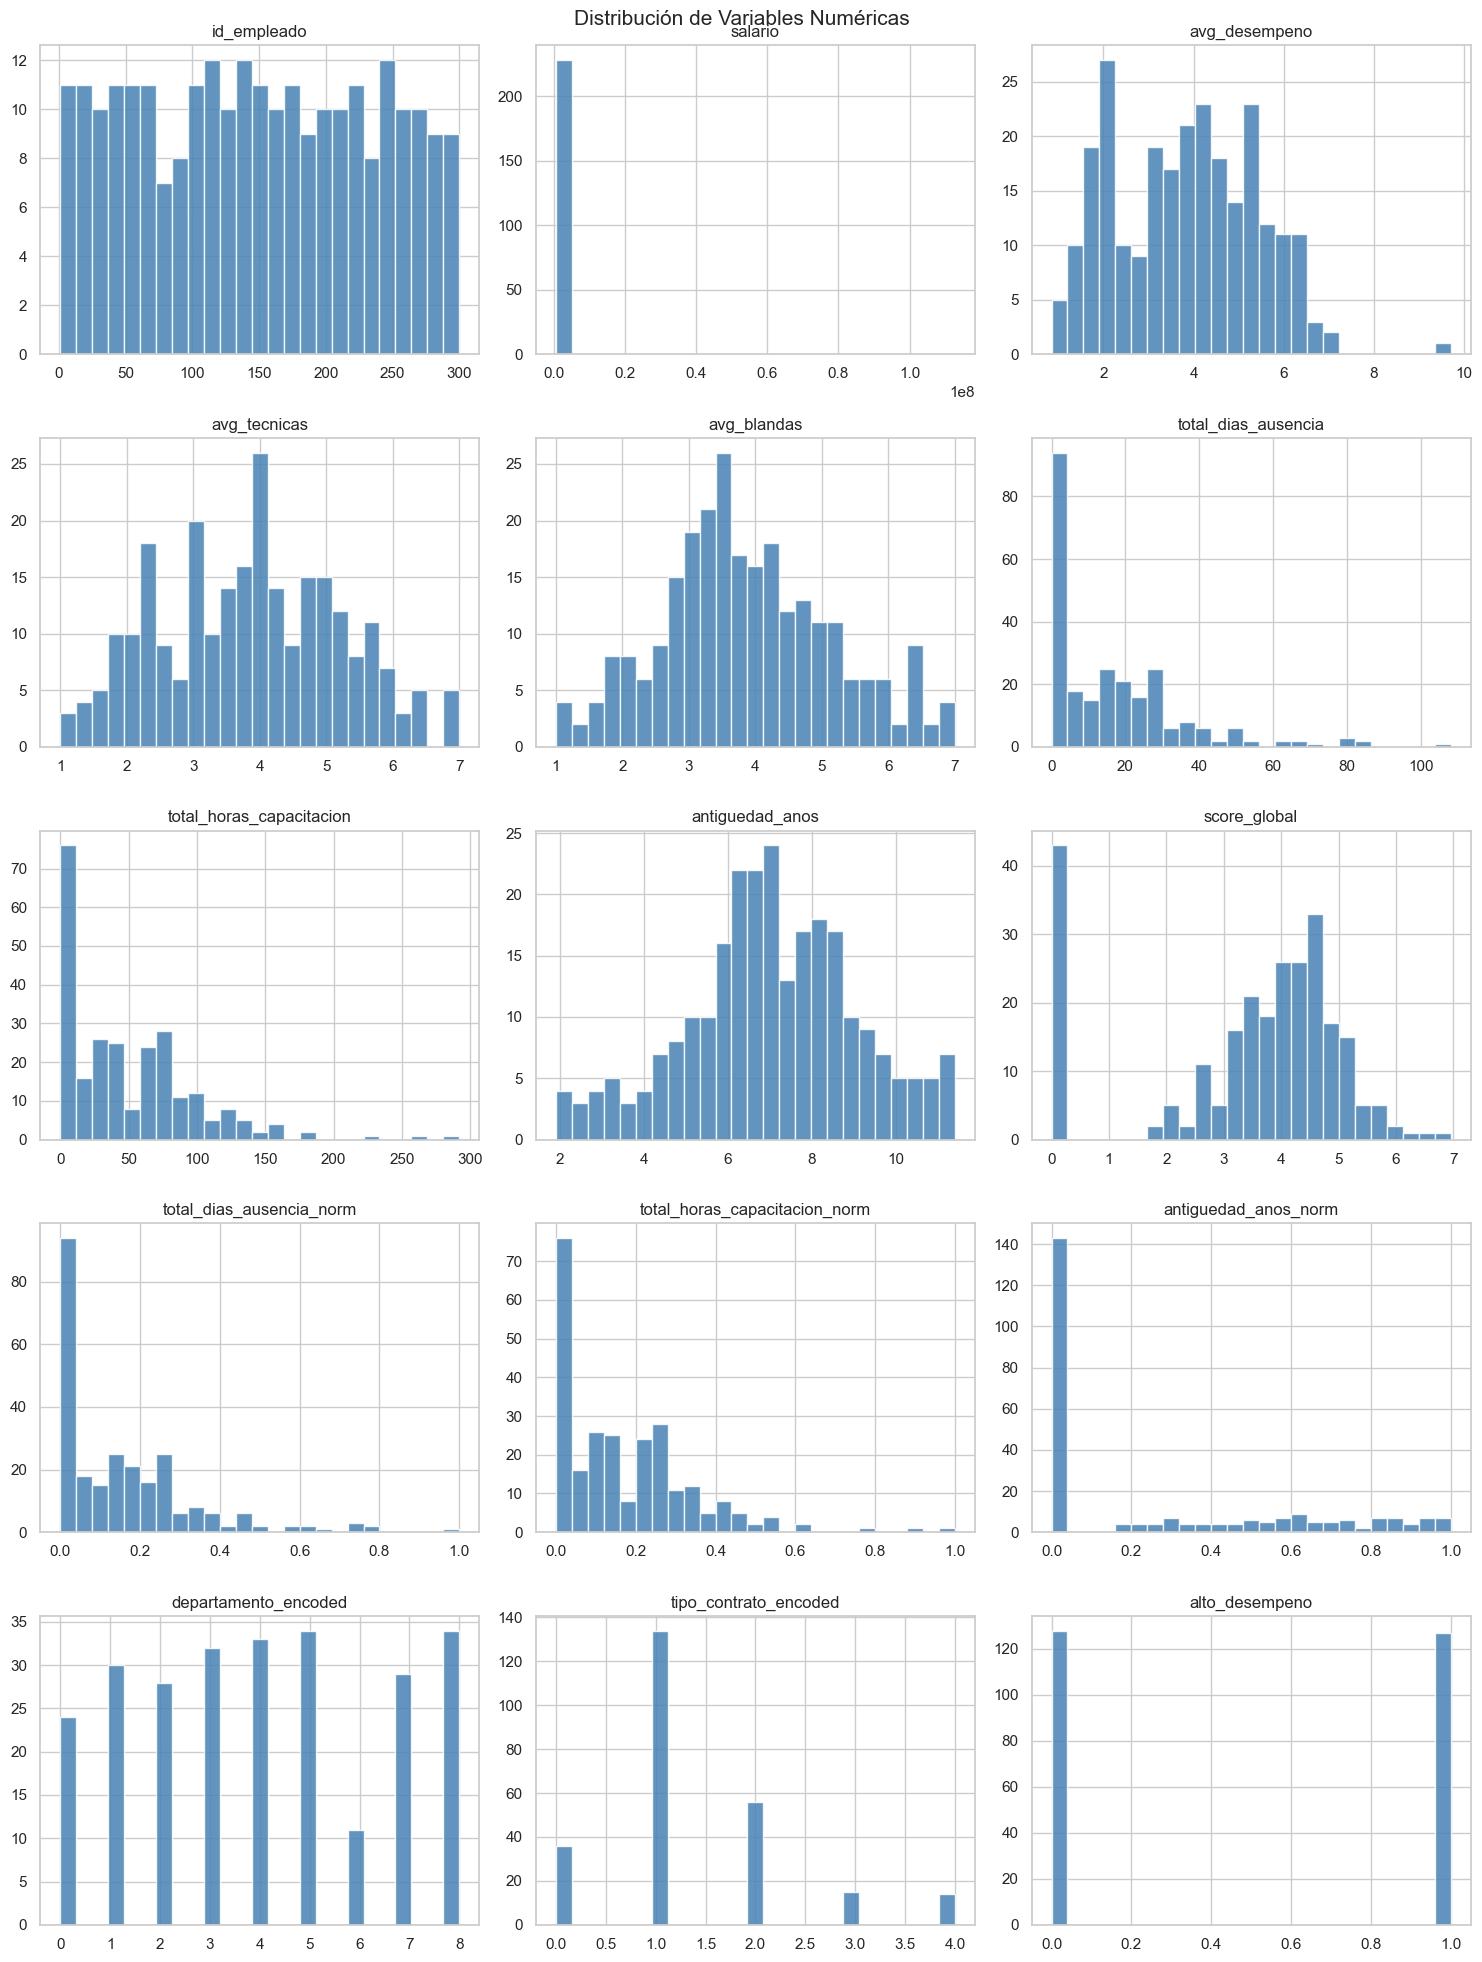

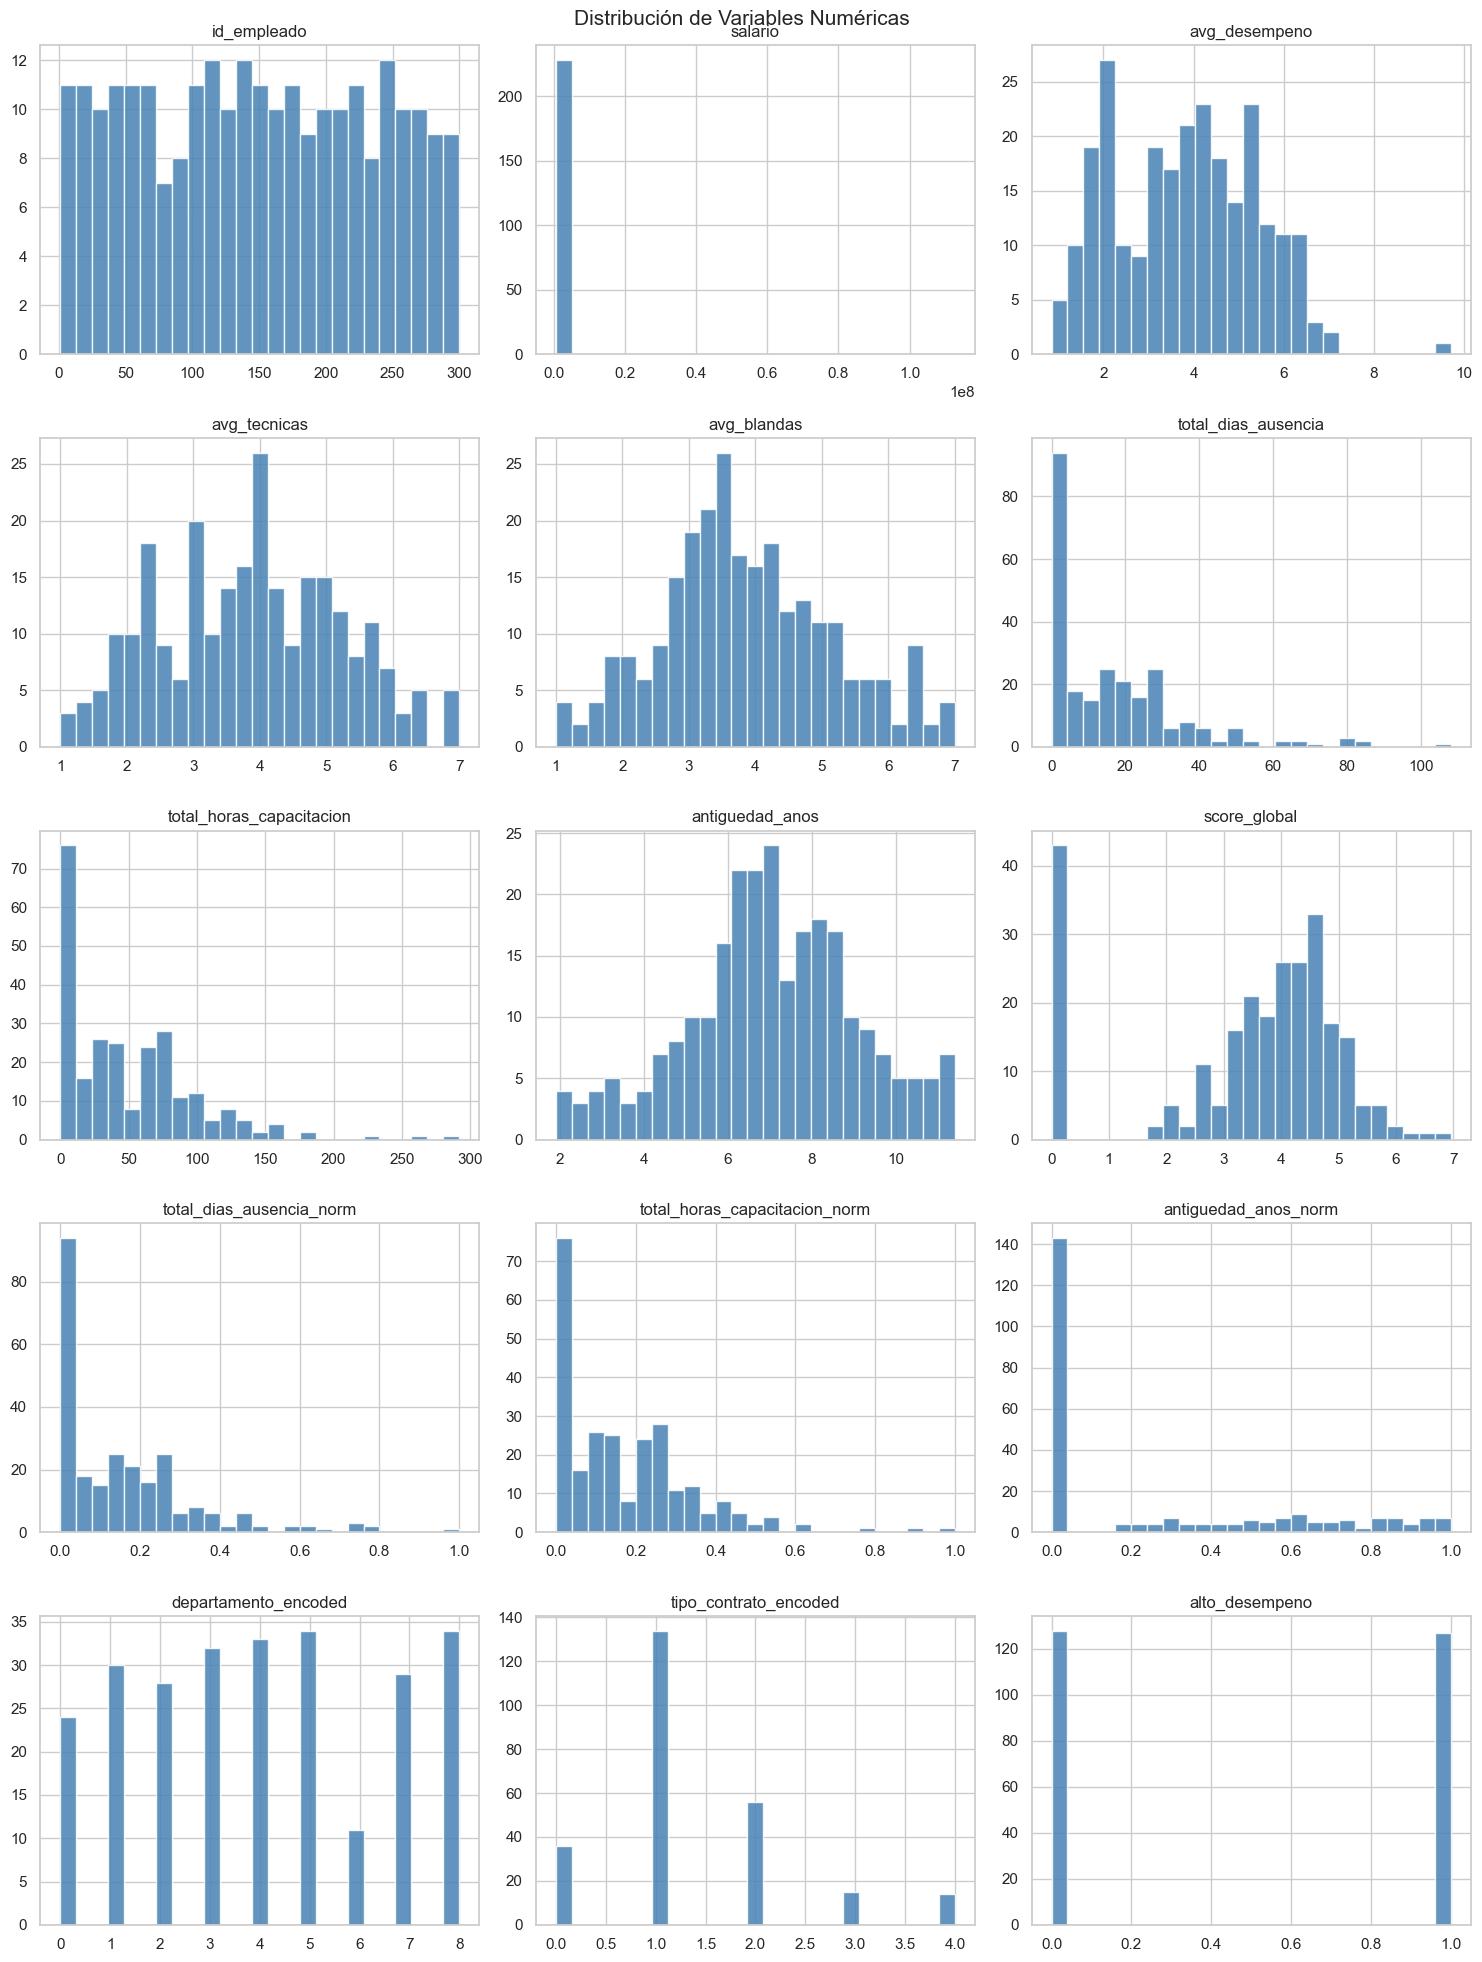

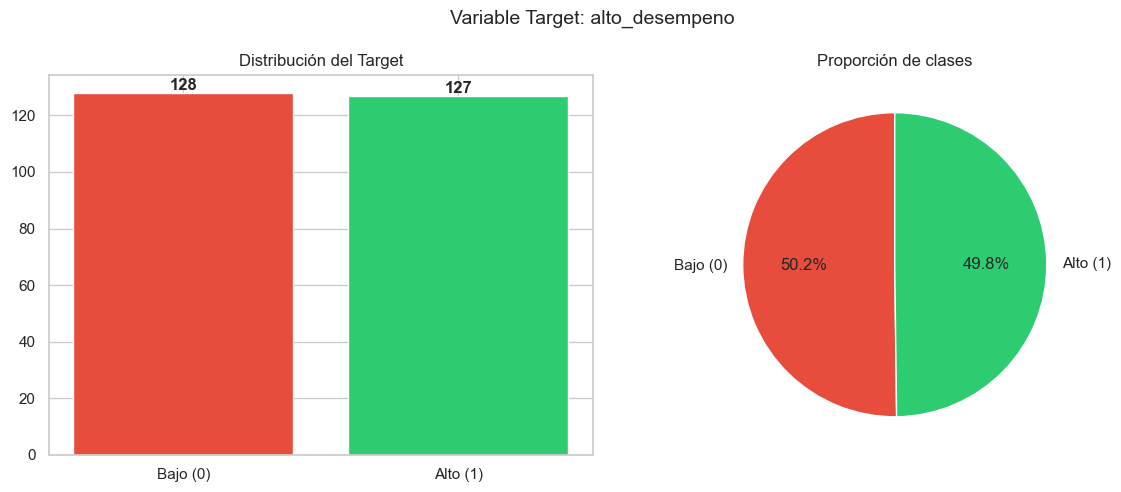

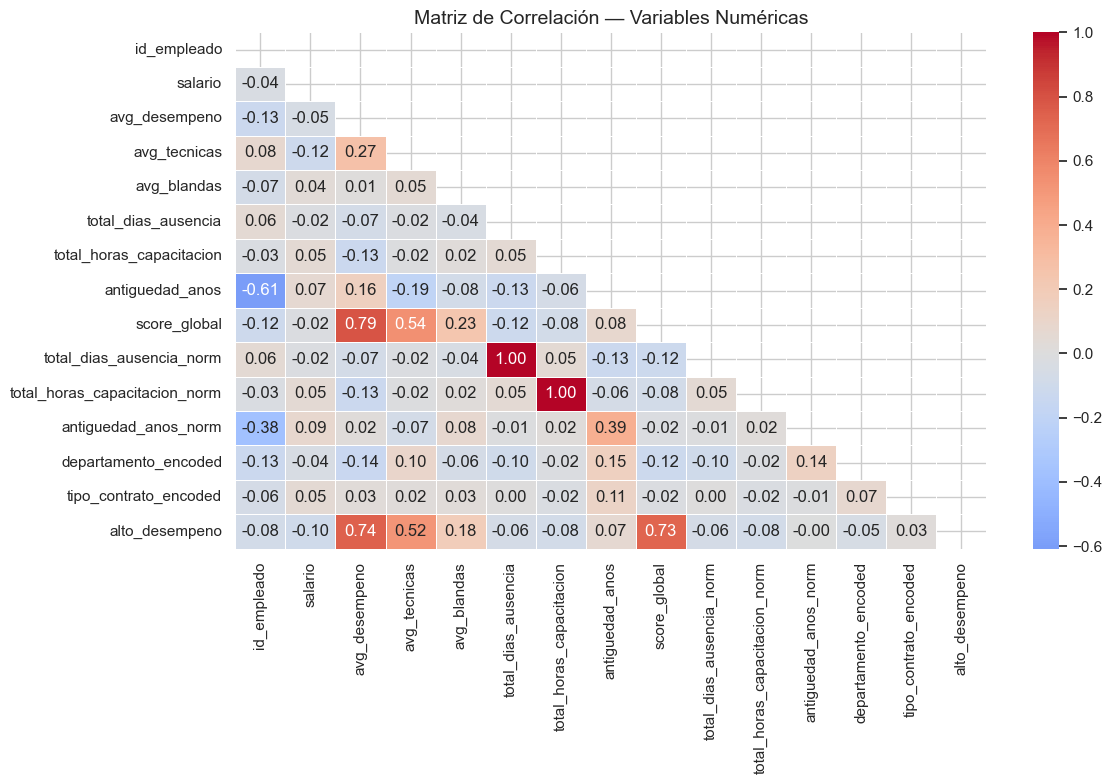

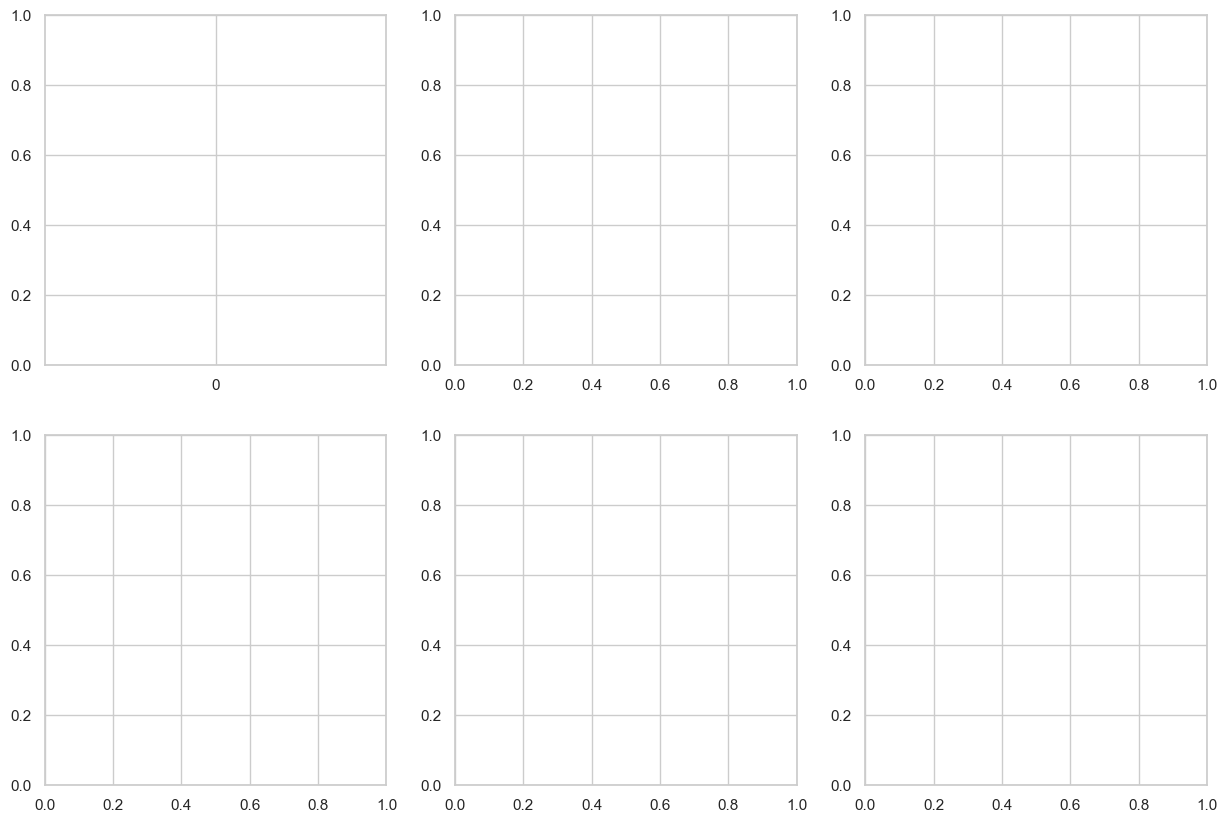

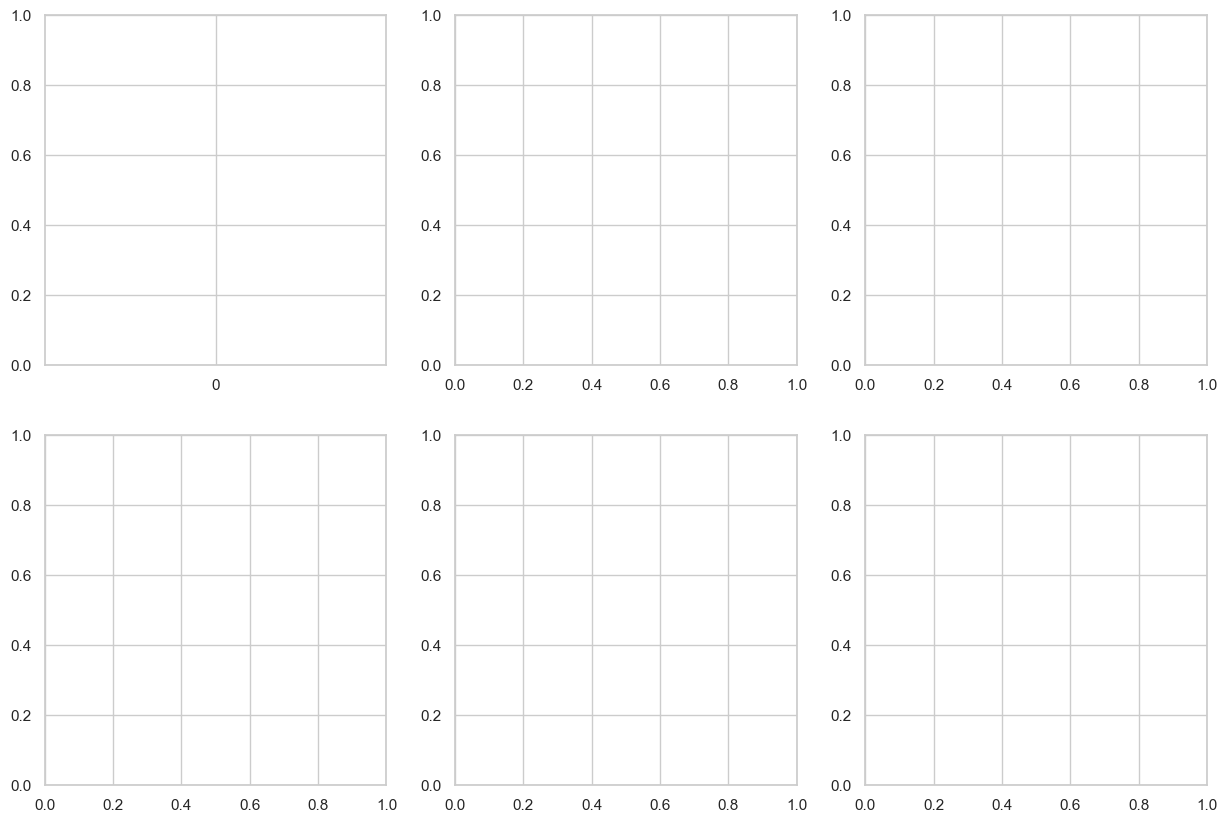

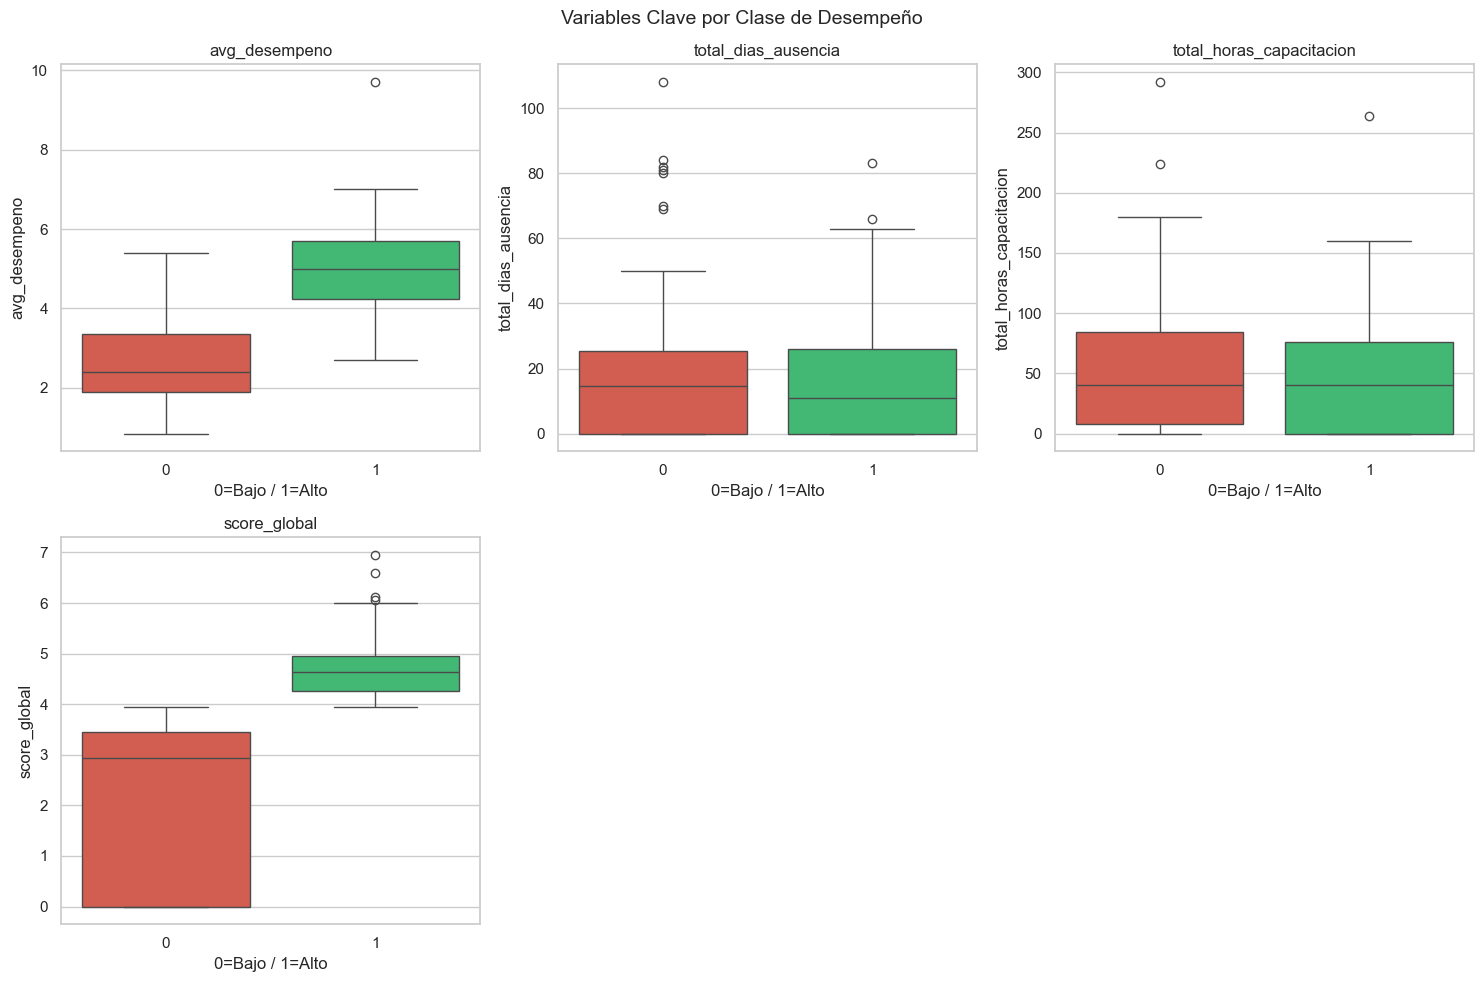

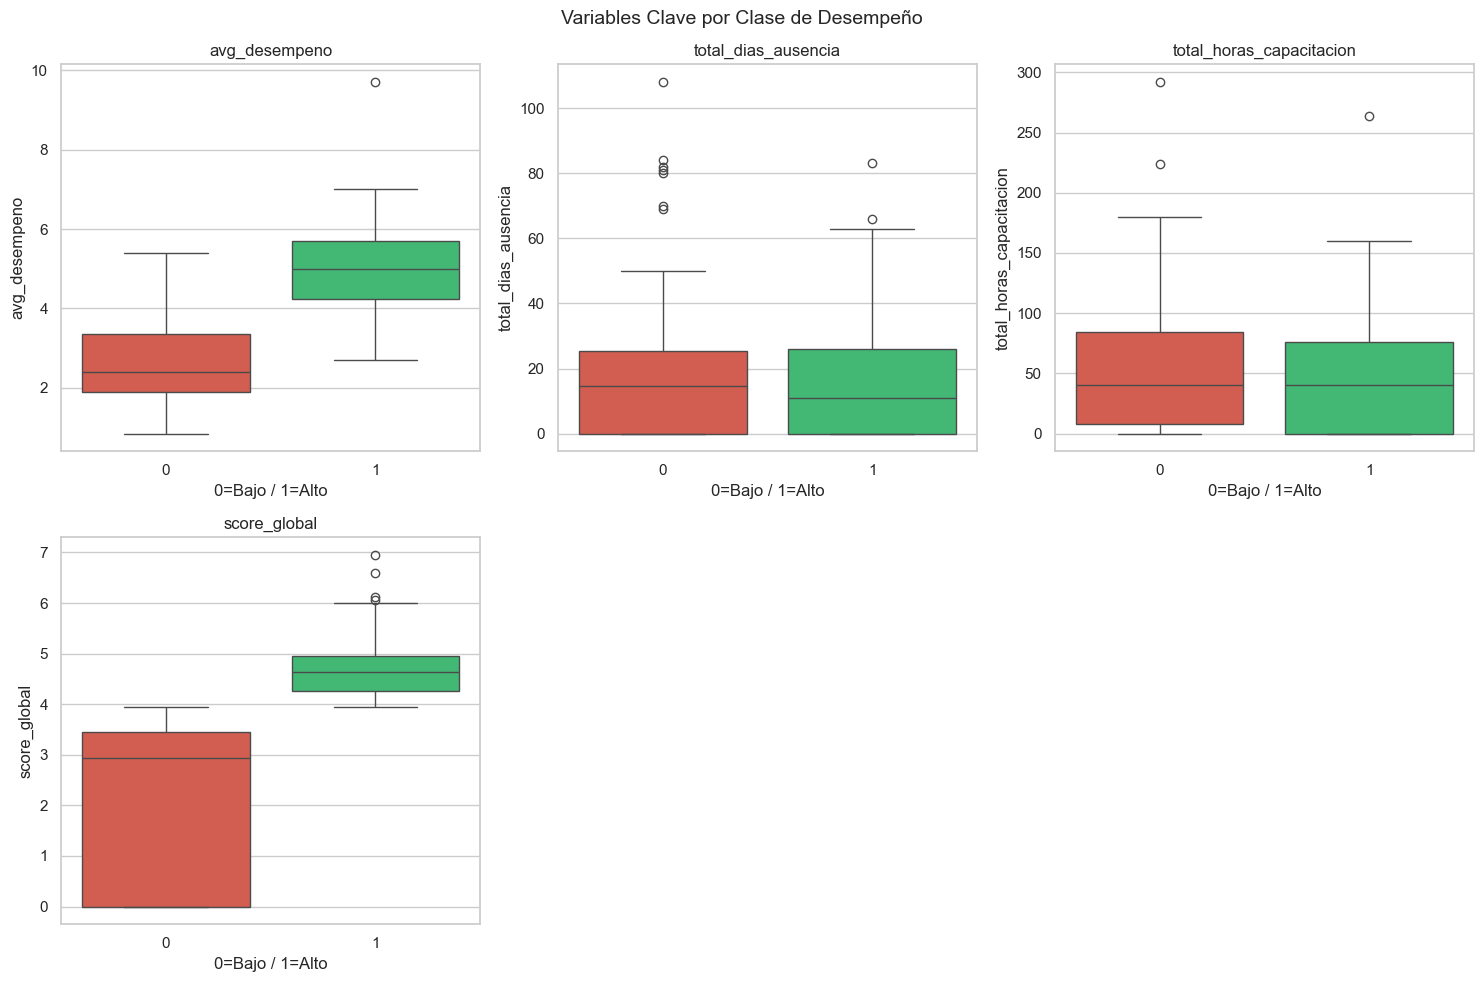

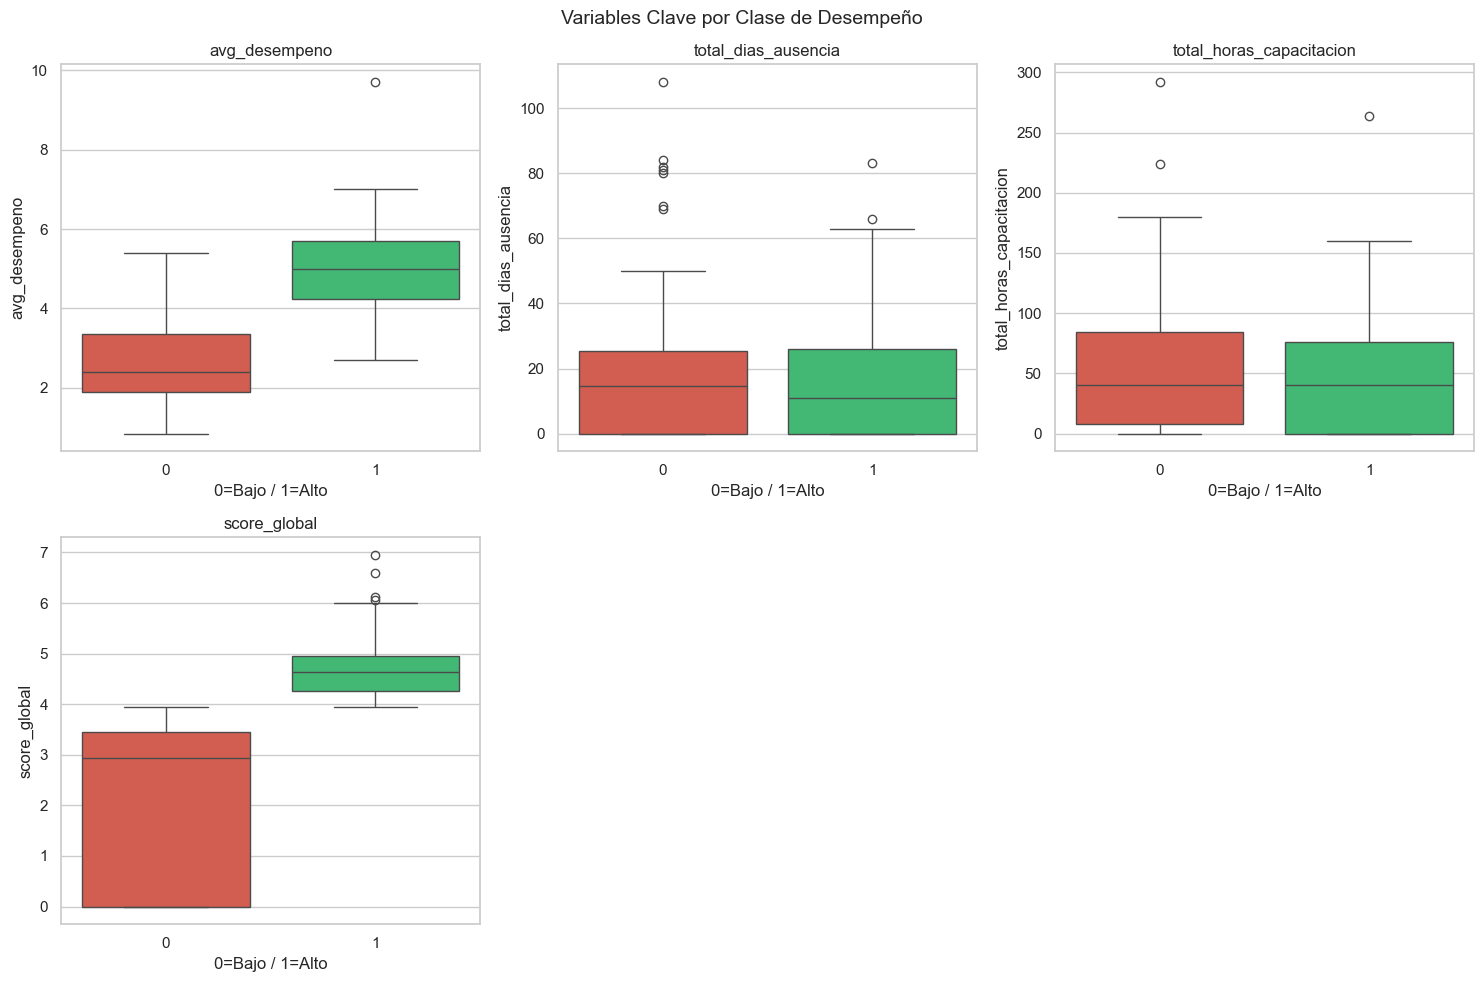

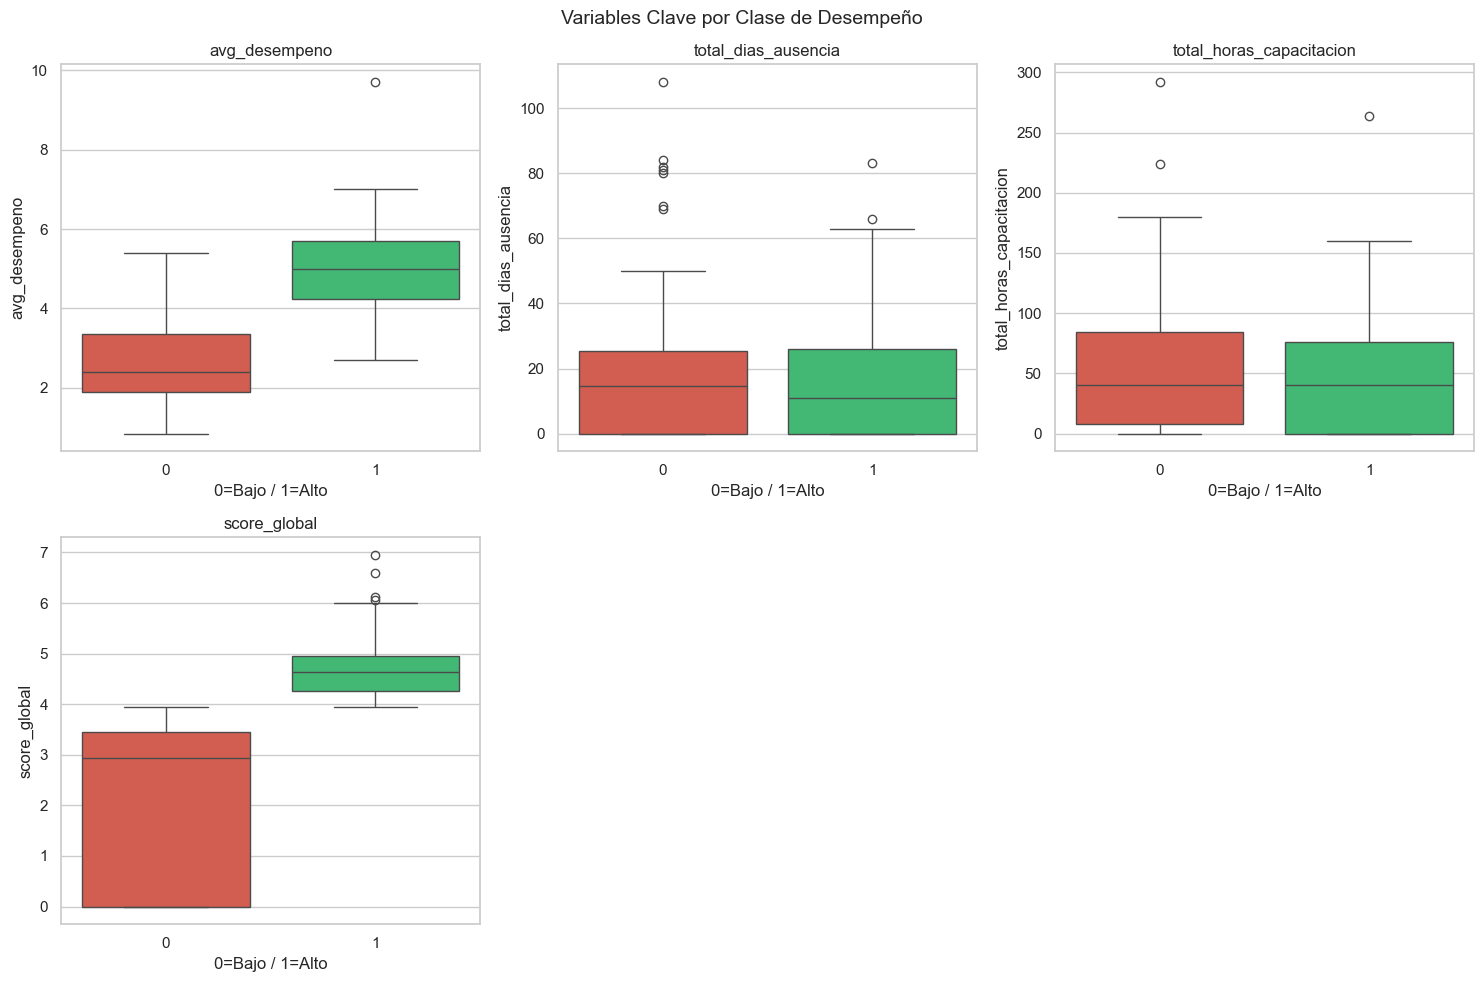

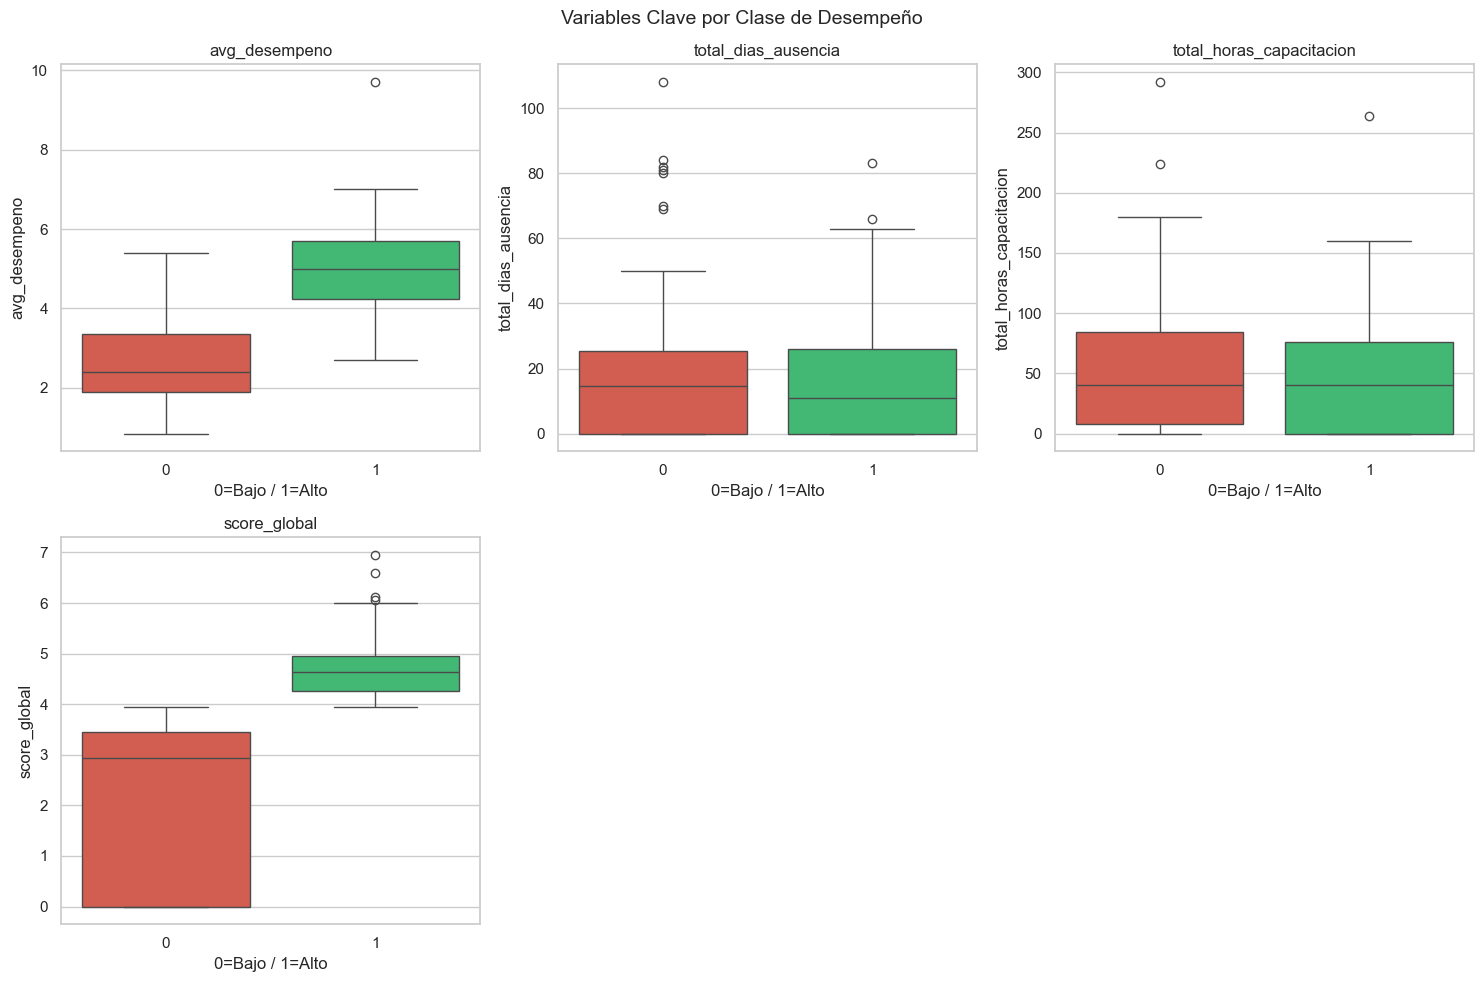

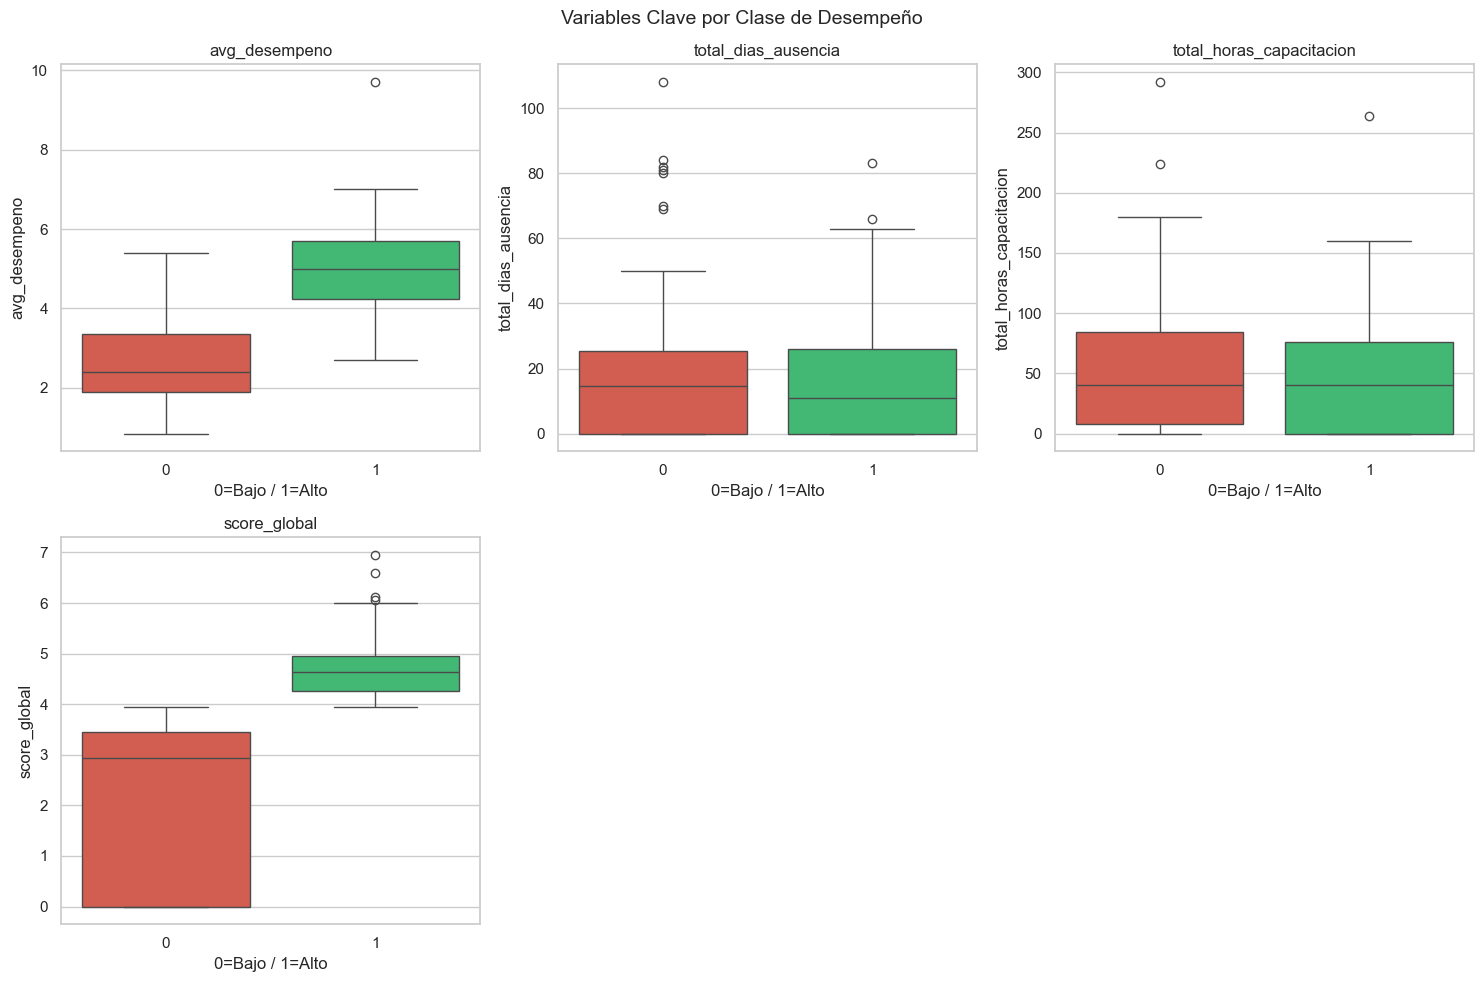

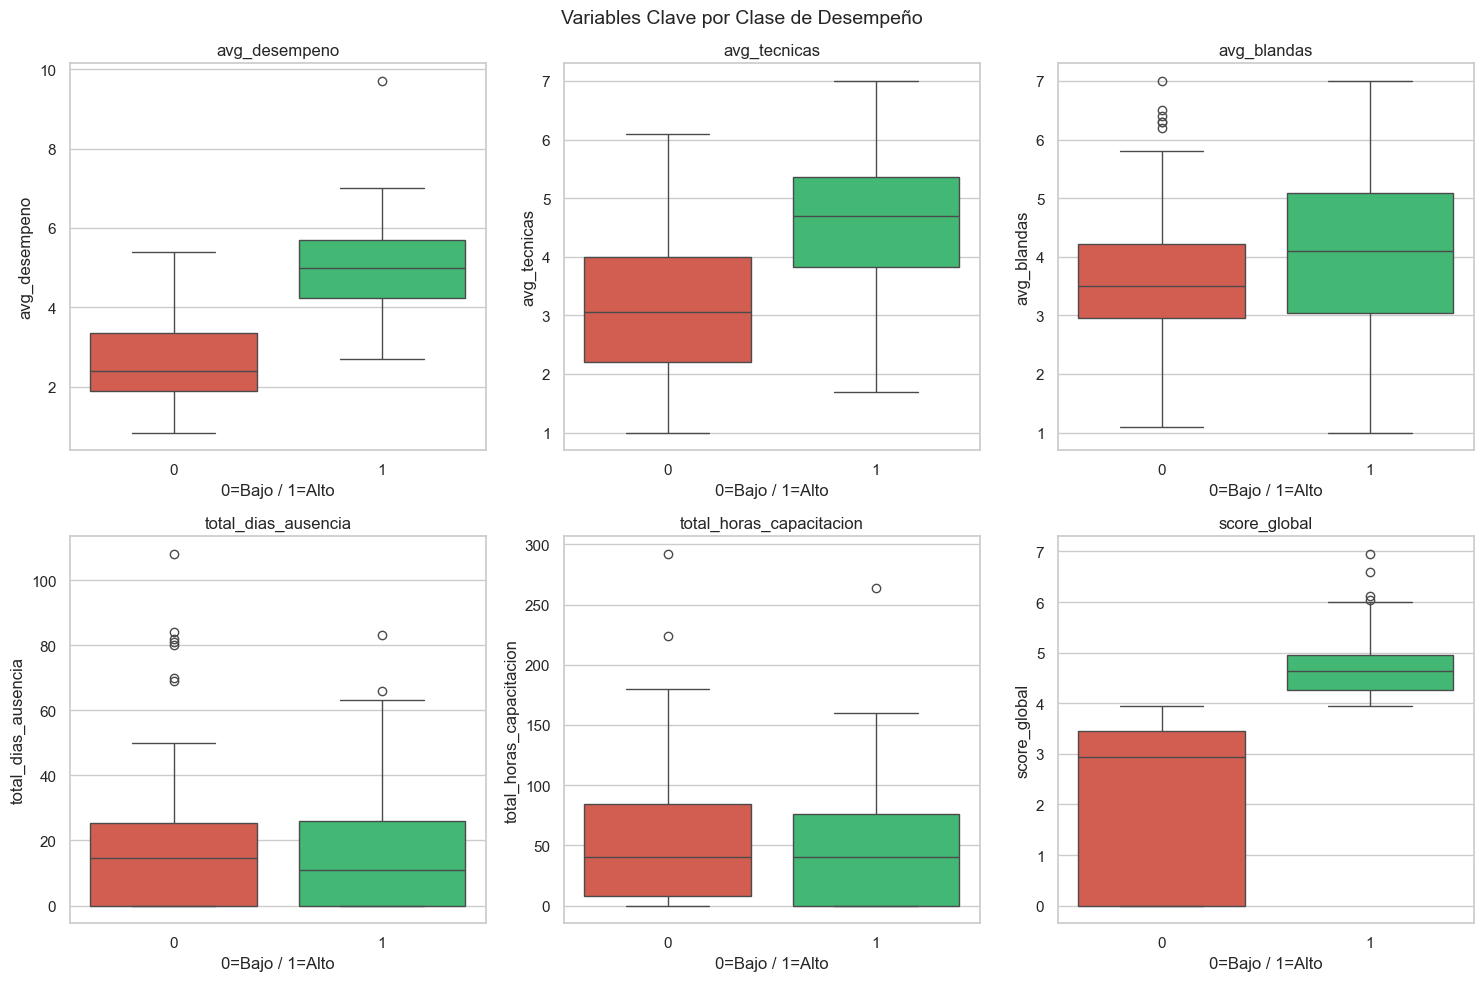

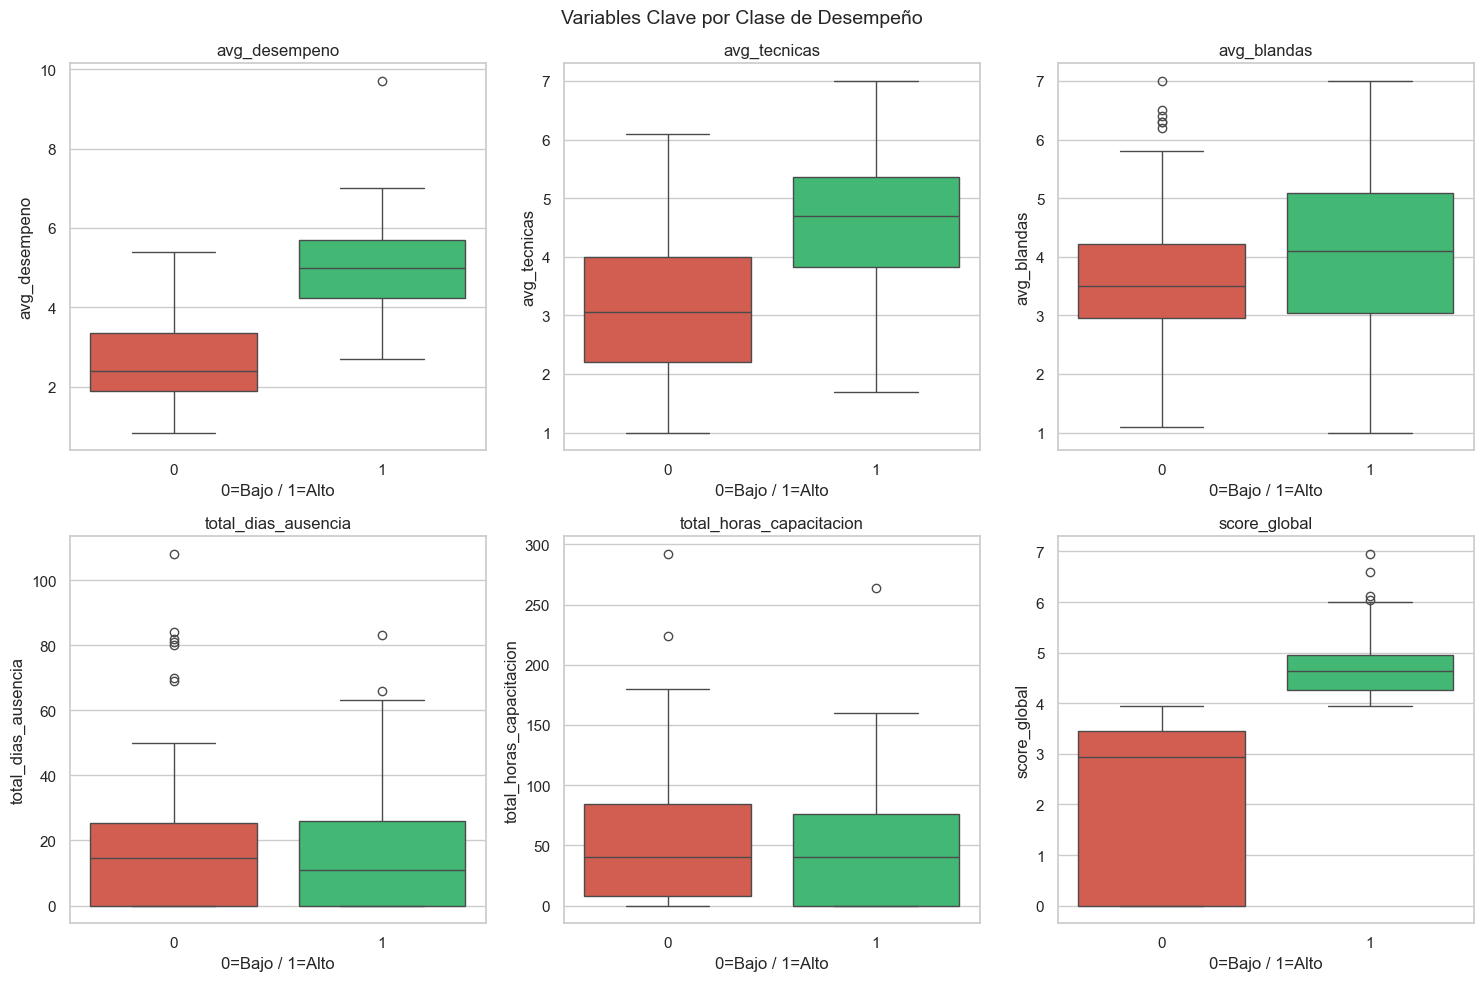

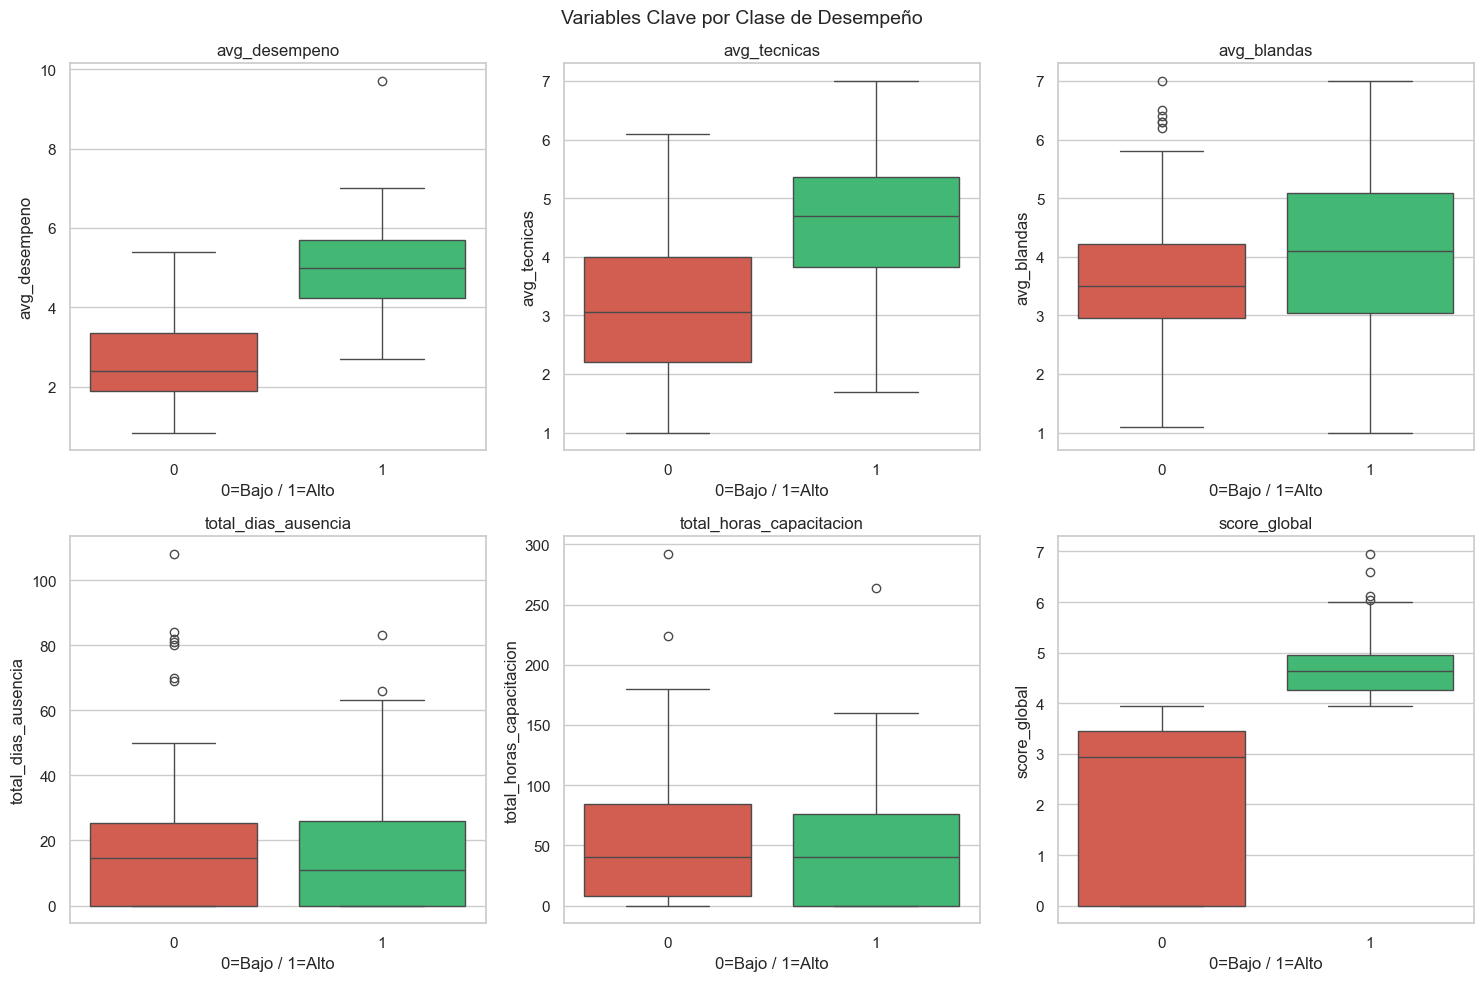

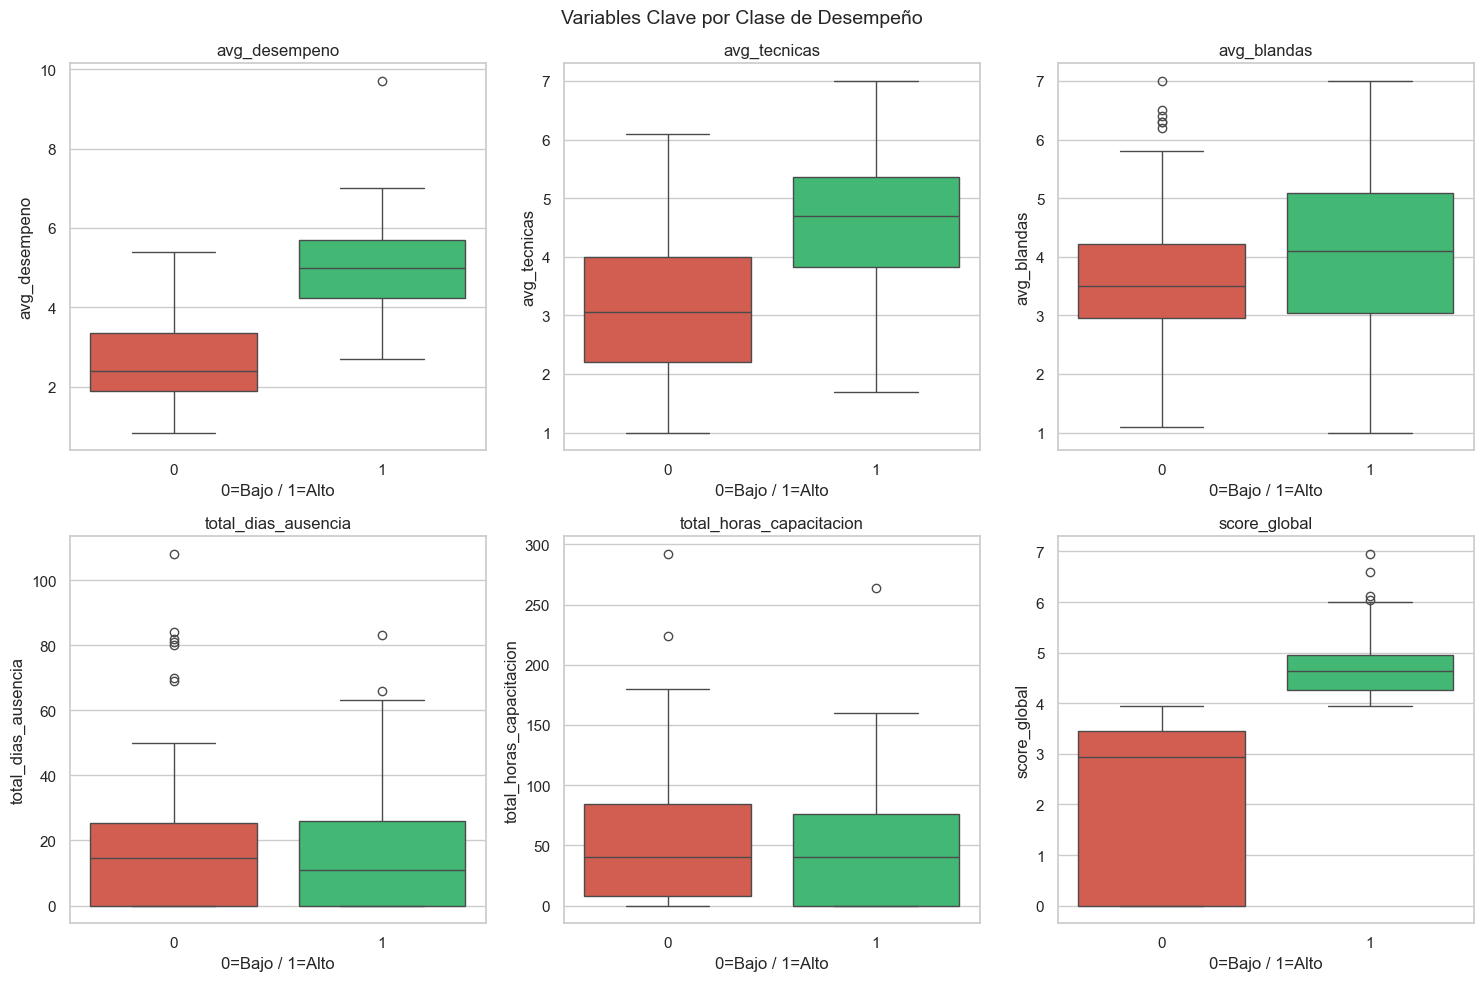

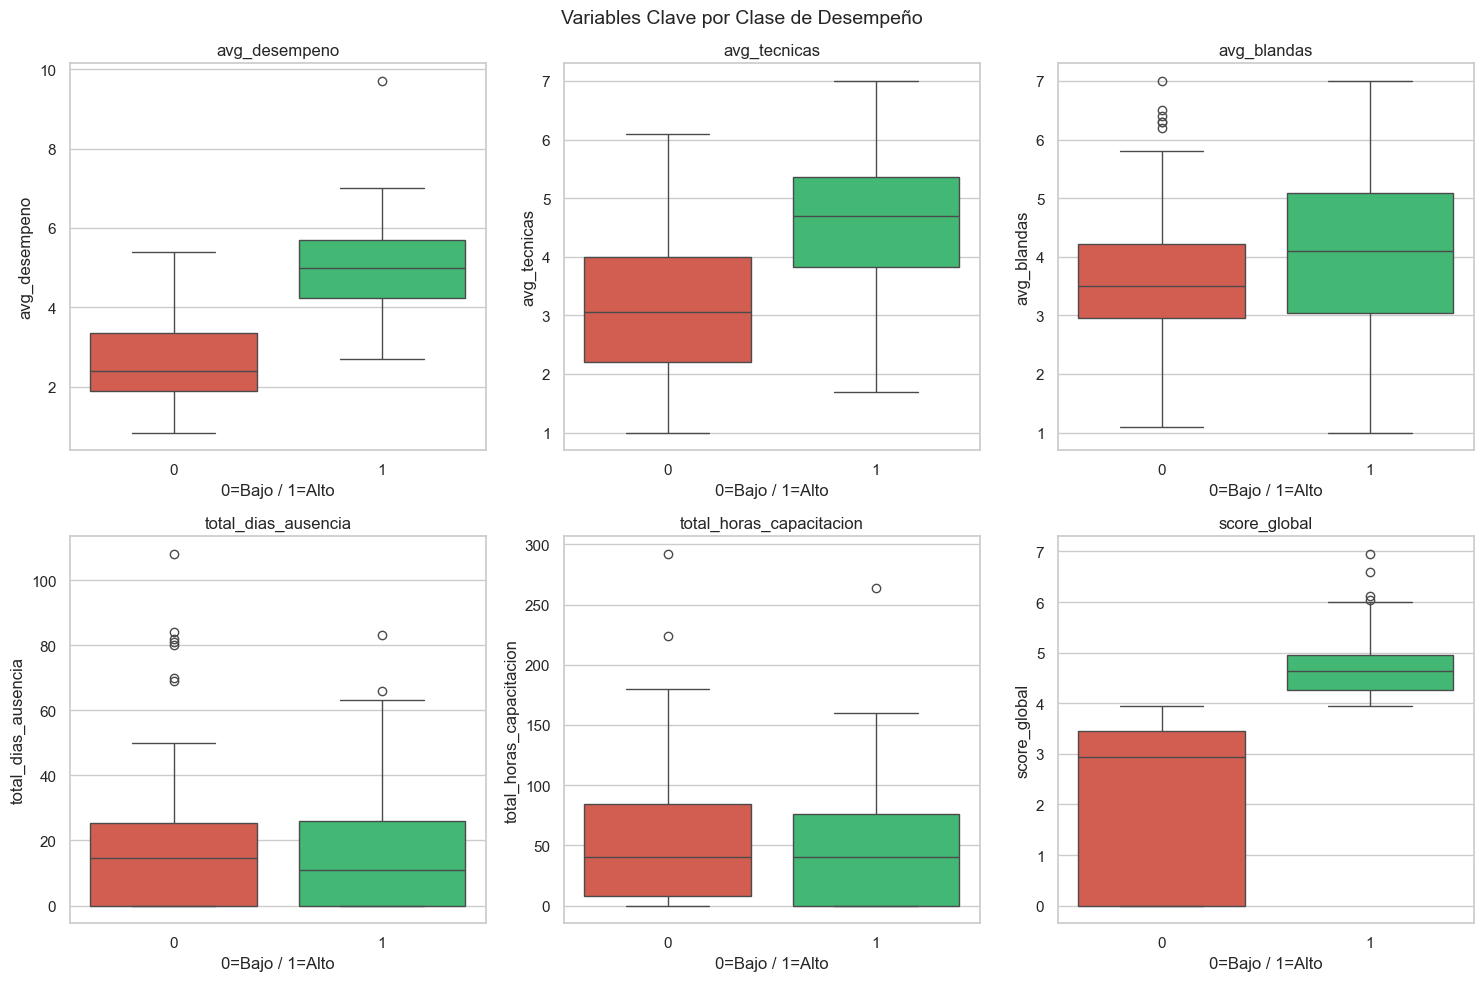

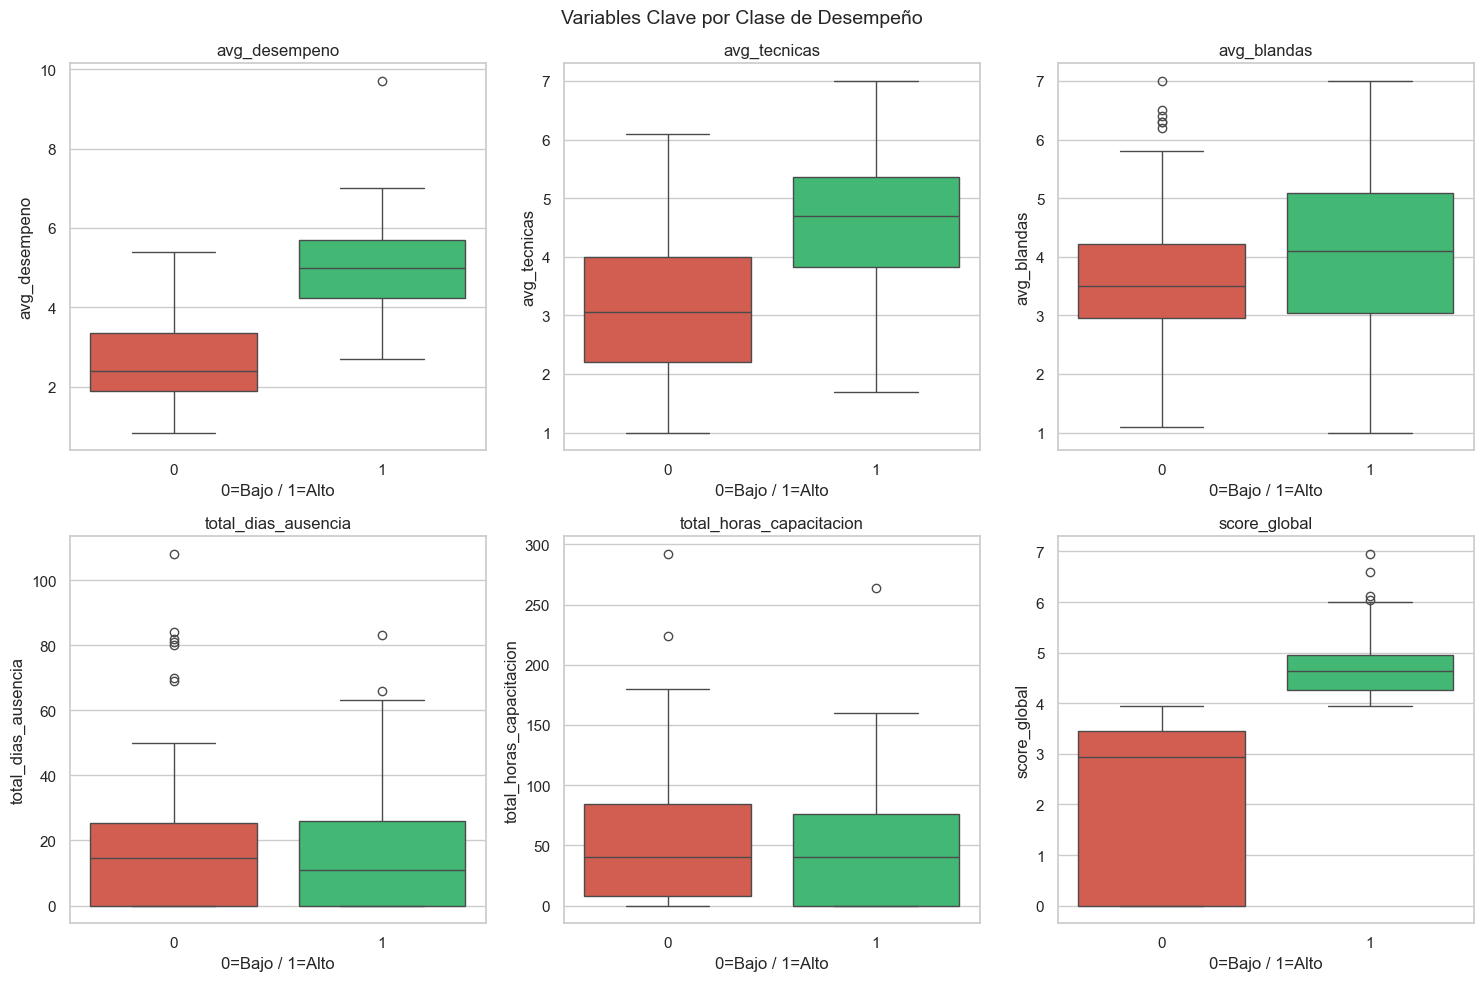

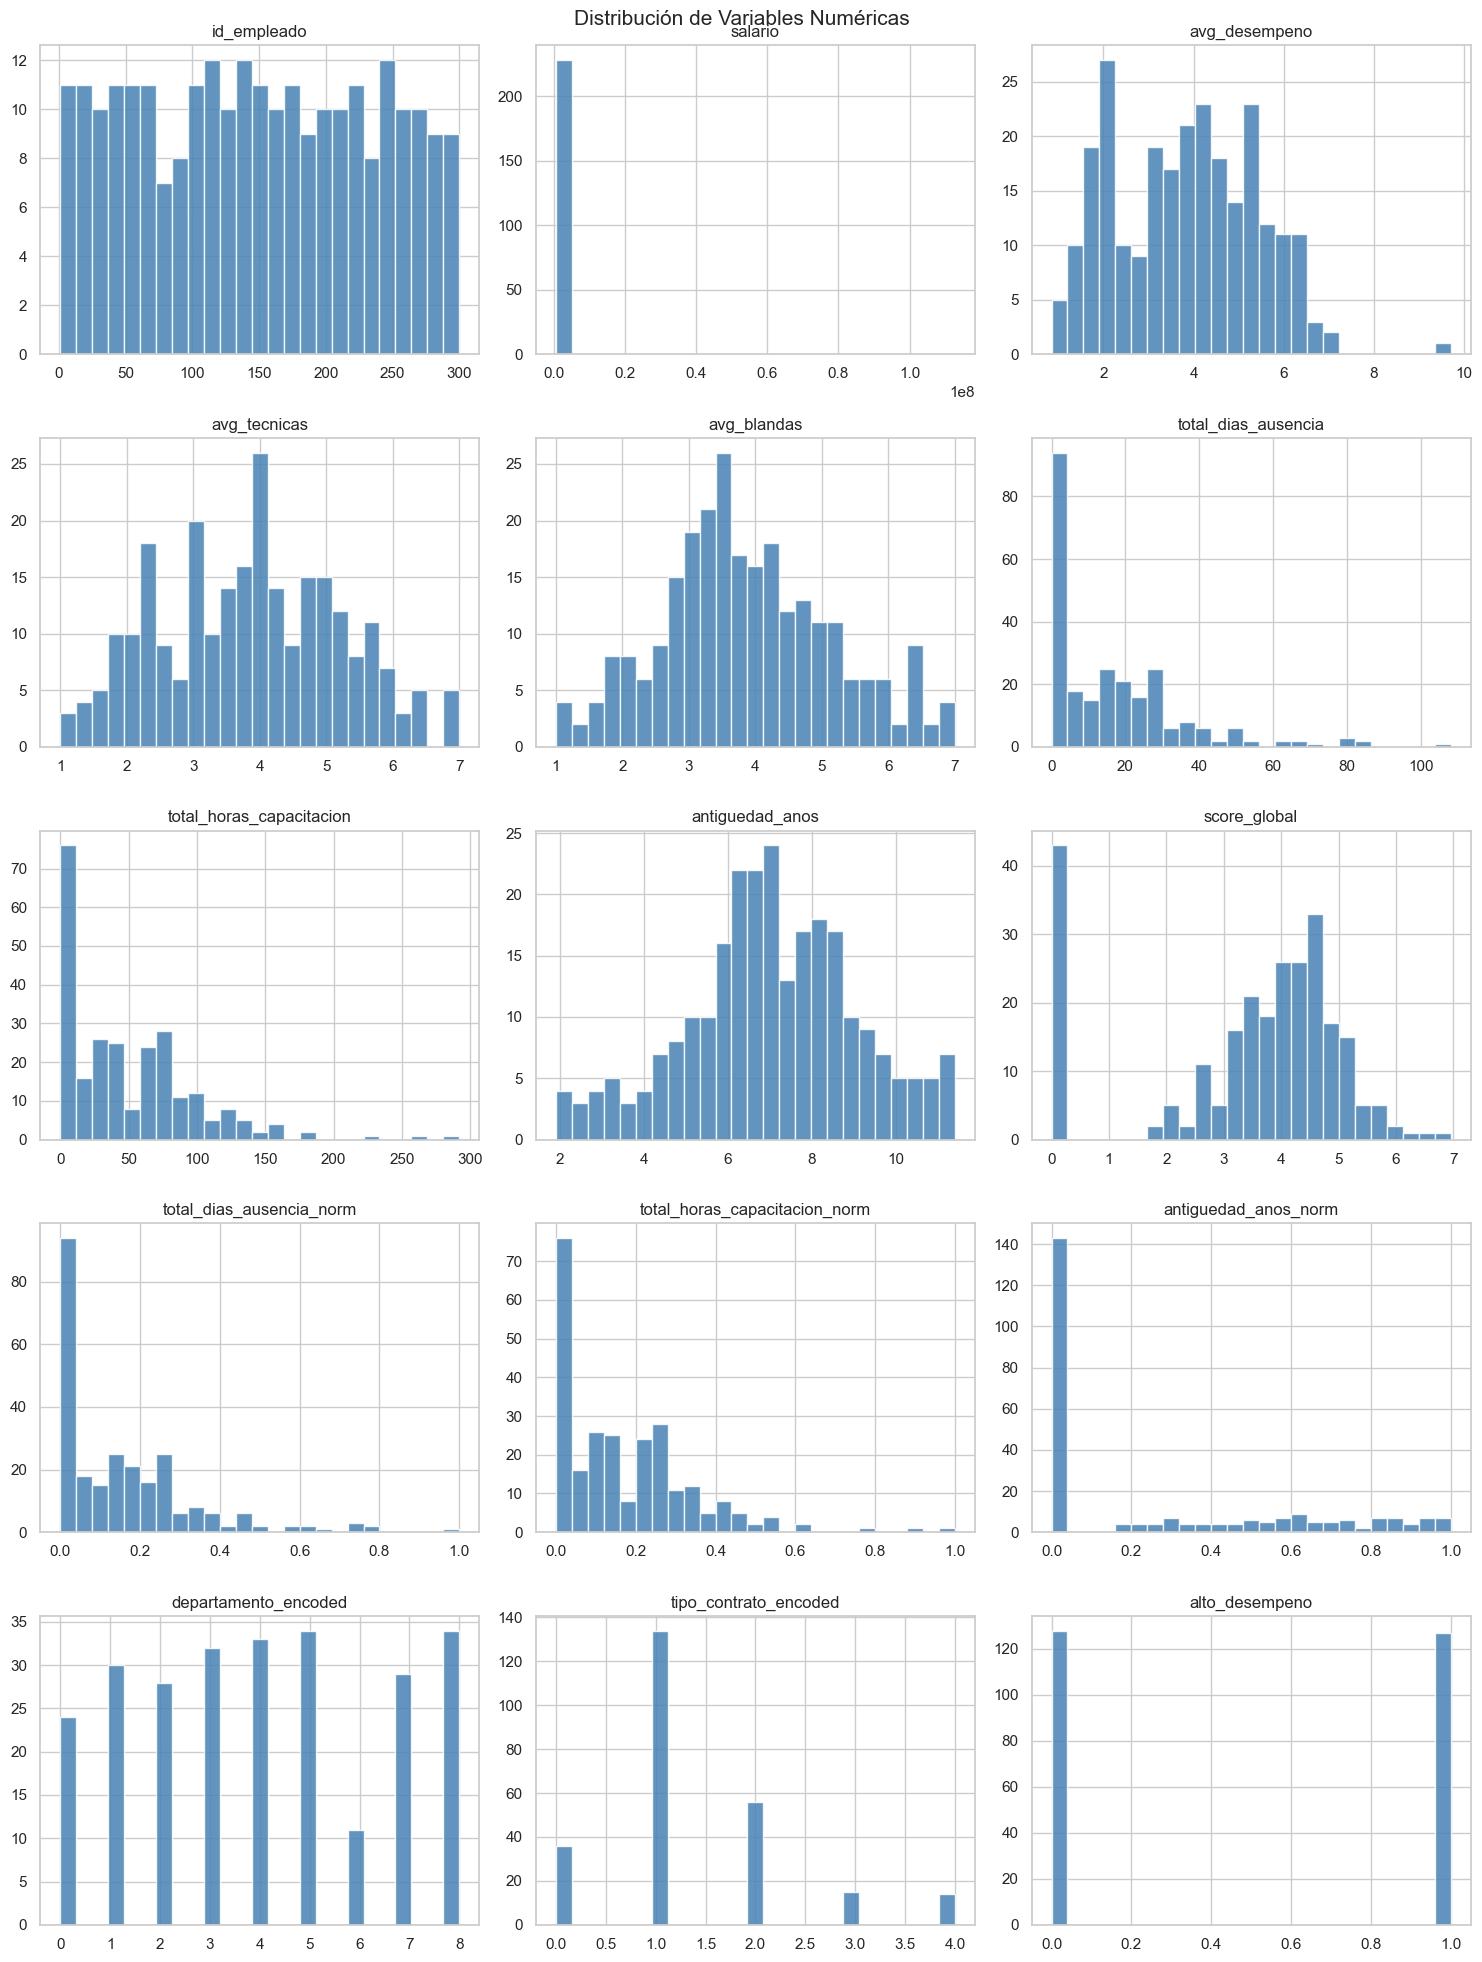

✅ Guardado en results/plots/


In [28]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = [c for c in num_cols if c.startswith('dep_') or c.startswith('cargo_')
           or c.startswith('contrato_') or c.startswith('jornada_')]
num_features = [c for c in num_cols if c not in exclude]

n = len(num_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas', fontsize=15)
plt.tight_layout()
plt.savefig('../results/plots/01_distribucion.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Guardado en results/plots/')

## 4. Distribución del Target: `alto_desempeno`

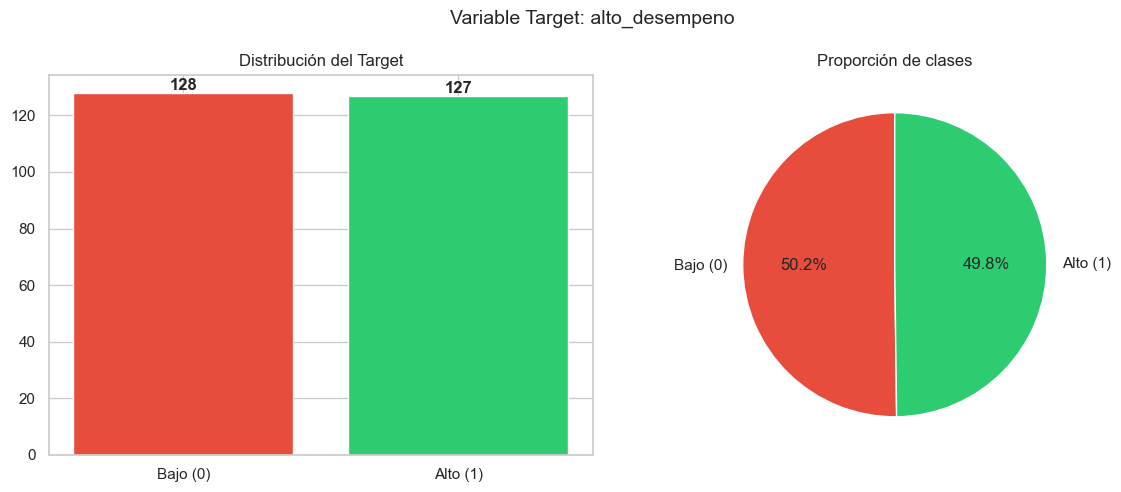

Ratio balance: 0.992 → ✅ Balanceado


In [29]:
target_clf = 'alto_desempeno'
conteo = df[target_clf].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['Bajo (0)', 'Alto (1)'], conteo.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Distribución del Target')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['Bajo (0)', 'Alto (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporción de clases')

plt.suptitle('Variable Target: alto_desempeno', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/01_target.png', bbox_inches='tight', dpi=120)
plt.show()

balance = conteo.min() / conteo.max()
print(f'Ratio balance: {balance:.3f} → {"⚠️ Desbalanceado" if balance < 0.7 else "✅ Balanceado"}')

## 5. Matriz de Correlación

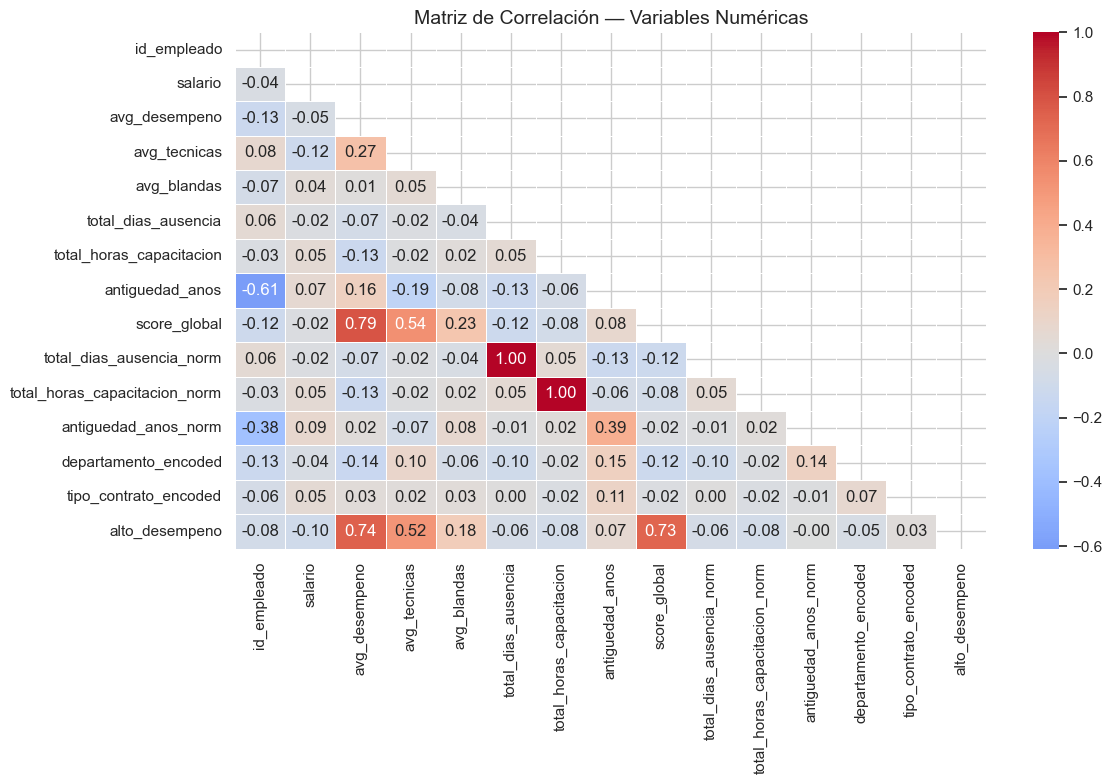


Top correlaciones con alto_desempeno:
alto_desempeno                   1.000
avg_desempeno                    0.744
score_global                     0.729
avg_tecnicas                     0.517
avg_blandas                      0.184
salario                          0.097
total_horas_capacitacion_norm    0.084
total_horas_capacitacion         0.084
Name: alto_desempeno, dtype: float64


In [30]:
corr_cols = [c for c in num_features if c in df.columns]
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/01_correlacion.png', bbox_inches='tight', dpi=120)
plt.show()

if target_clf in corr_matrix.columns:
    print('\nTop correlaciones con alto_desempeno:')
    print(corr_matrix[target_clf].abs().sort_values(ascending=False).head(8).round(3))

## 6. Boxplots: Variables Clave vs Target

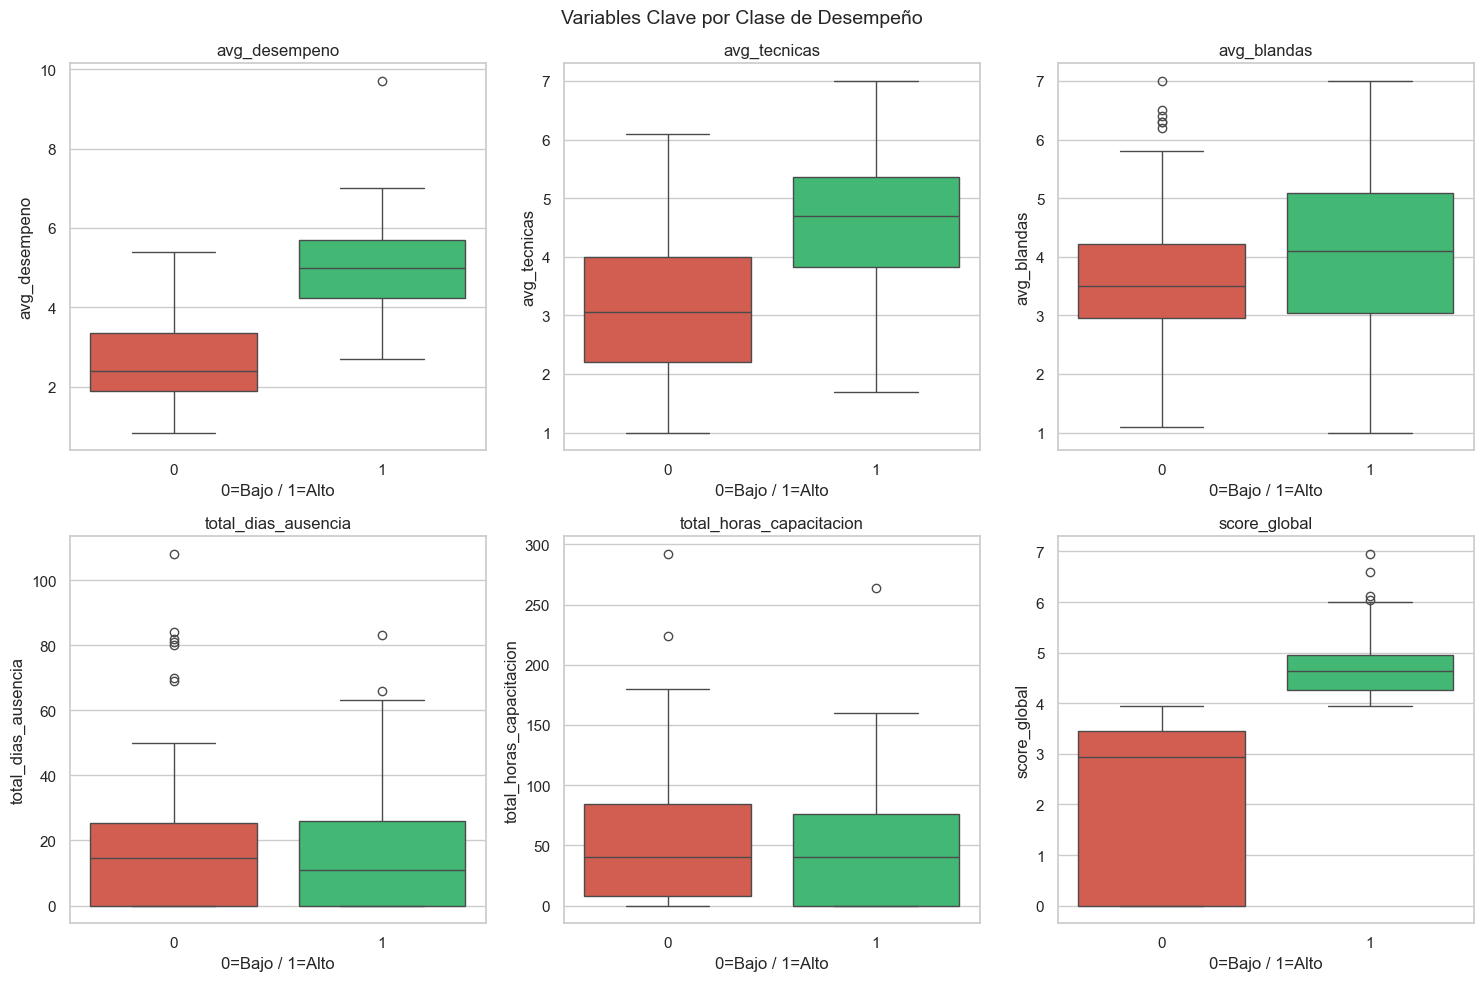

In [31]:
key_vars = ['avg_desempeno', 'avg_tecnicas', 'avg_blandas',
            'total_dias_ausencia', 'total_horas_capacitacion', 'score_global']
key_vars = [v for v in key_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    sns.boxplot(data=df, x=target_clf, y=var,
                palette={'0': '#e74c3c', '1': '#2ecc71'}, ax=axes[i])
    axes[i].set_title(f'{var}')
    axes[i].set_xlabel('0=Bajo / 1=Alto')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables Clave por Clase de Desempeño', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/01_boxplots.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 7. PCA — Reducción de Dimensionalidad

> **IEE 2.1.2:** Aprendizaje no supervisado — reducción de dimensionalidad.

In [32]:
exclude_for_unsup = ['alto_desempeno', 'avg_desempeno', 'score_global', 'id_empleado']
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude_for_unsup]

X_unsup = df[feature_cols].dropna()
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_unsup)

print(f'Shape para PCA/KMeans: {X_unsup.shape}')
print('✅ Datos escalados con StandardScaler')

Shape para PCA/KMeans: (232, 13)
✅ Datos escalados con StandardScaler


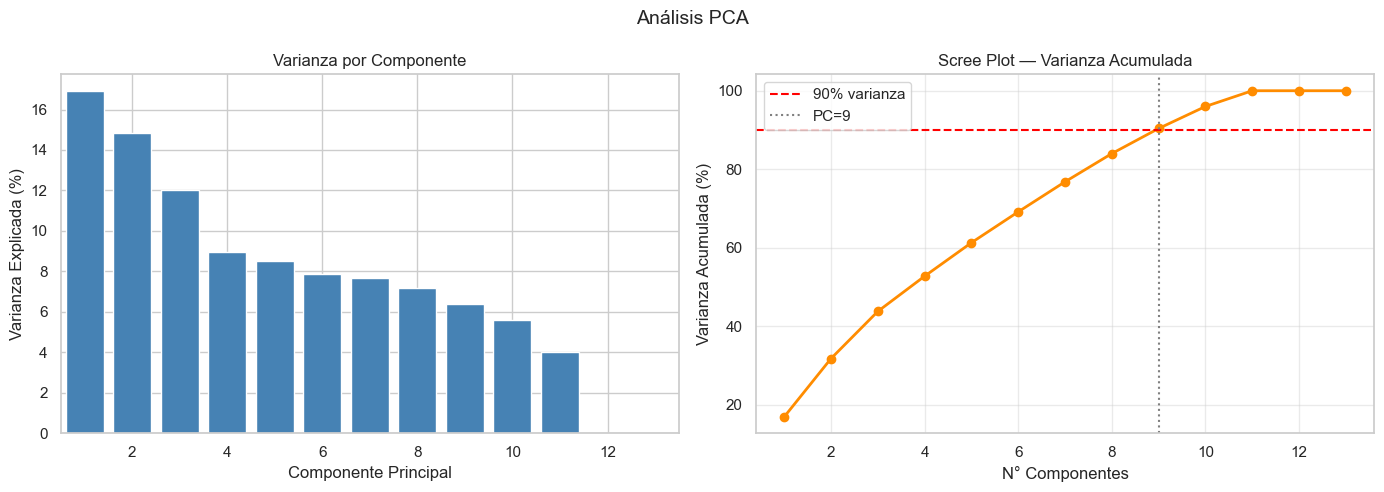

Componentes para 90% varianza: 9
PC1: 16.9%  |  PC2: 14.9%


In [33]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = np.argmax(varianza_acum >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza por Componente')
axes[0].set_xlim(0.5, min(15, len(pca_full.explained_variance_ratio_)) + 0.5)

axes[1].plot(range(1, len(varianza_acum) + 1), varianza_acum * 100,
             marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', label='90% varianza')
axes[1].axvline(x=n_comp_90, color='gray', linestyle=':', label=f'PC={n_comp_90}')
axes[1].set_xlabel('N° Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Scree Plot — Varianza Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Análisis PCA', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/01_pca_varianza.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Componentes para 90% varianza: {n_comp_90}')
print(f'PC1: {pca_full.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca_full.explained_variance_ratio_[1]*100:.1f}%')

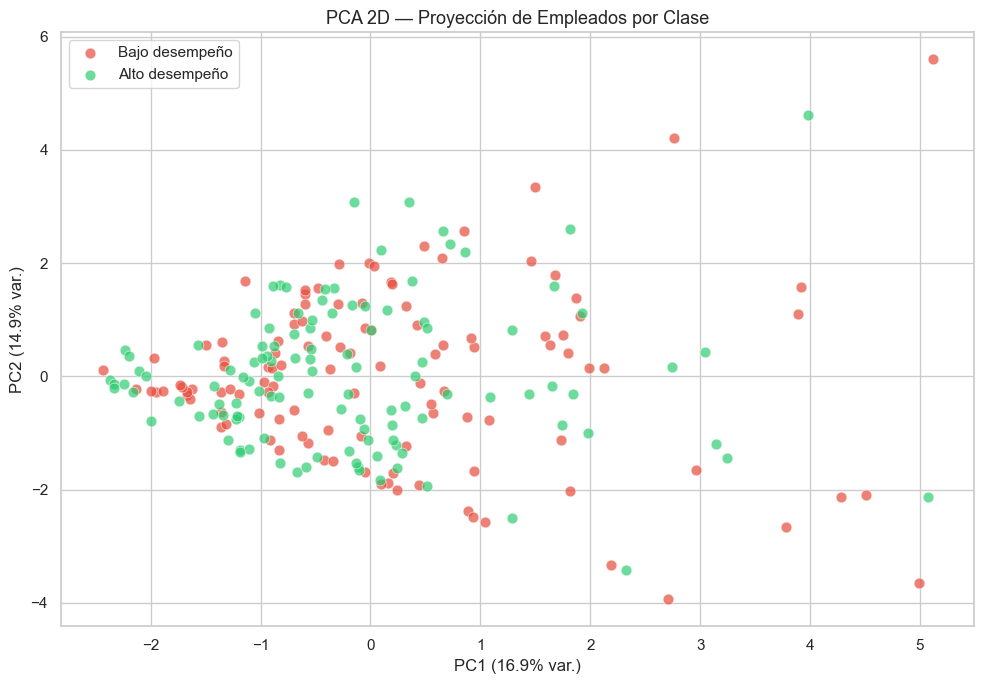

In [34]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
target_values = df.loc[X_unsup.index, target_clf]

plt.figure(figsize=(10, 7))
for clase, color, label in [(0, '#e74c3c', 'Bajo desempeño'), (1, '#2ecc71', 'Alto desempeño')]:
    mask = target_values == clase
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=label, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)', fontsize=12)
plt.title('PCA 2D — Proyección de Empleados por Clase', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/01_pca_2d.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. K-Means Clustering

> **IEE 2.1.2:** Aprendizaje no supervisado — clustering.

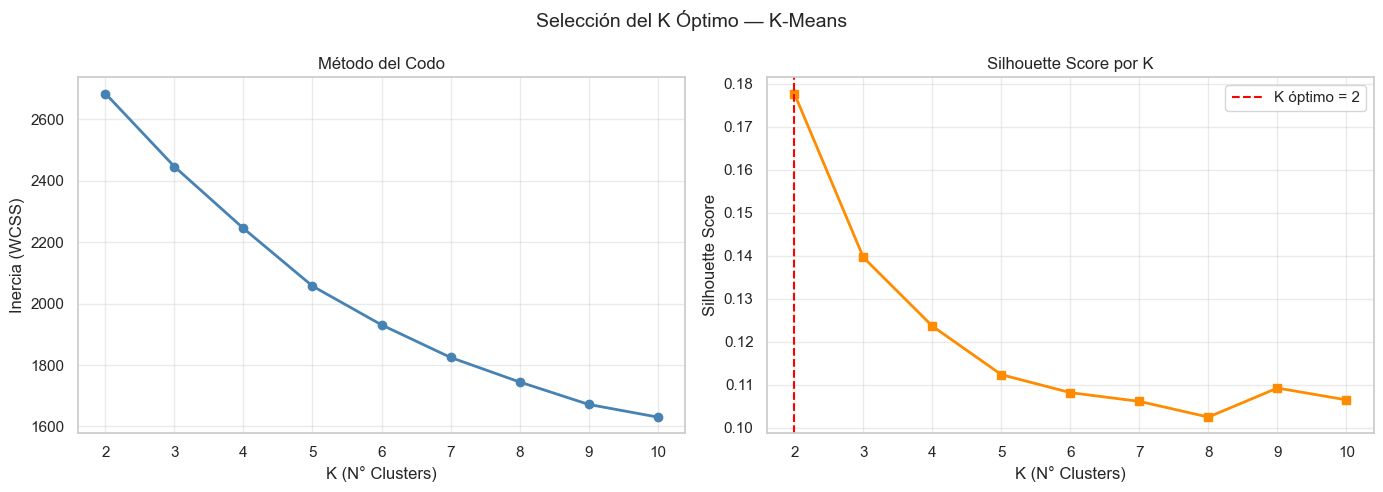

K óptimo: 2  |  Silhouette: 0.1778


In [35]:
K_range = range(2, 11)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('K (N° Clusters)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.4)

k_optimo = list(K_range)[np.argmax(silhouettes)]
axes[1].plot(K_range, silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(x=k_optimo, color='red', linestyle='--', label=f'K óptimo = {k_optimo}')
axes[1].set_xlabel('K (N° Clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Selección del K Óptimo — K-Means', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/01_kmeans_k.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'K óptimo: {k_optimo}  |  Silhouette: {max(silhouettes):.4f}')

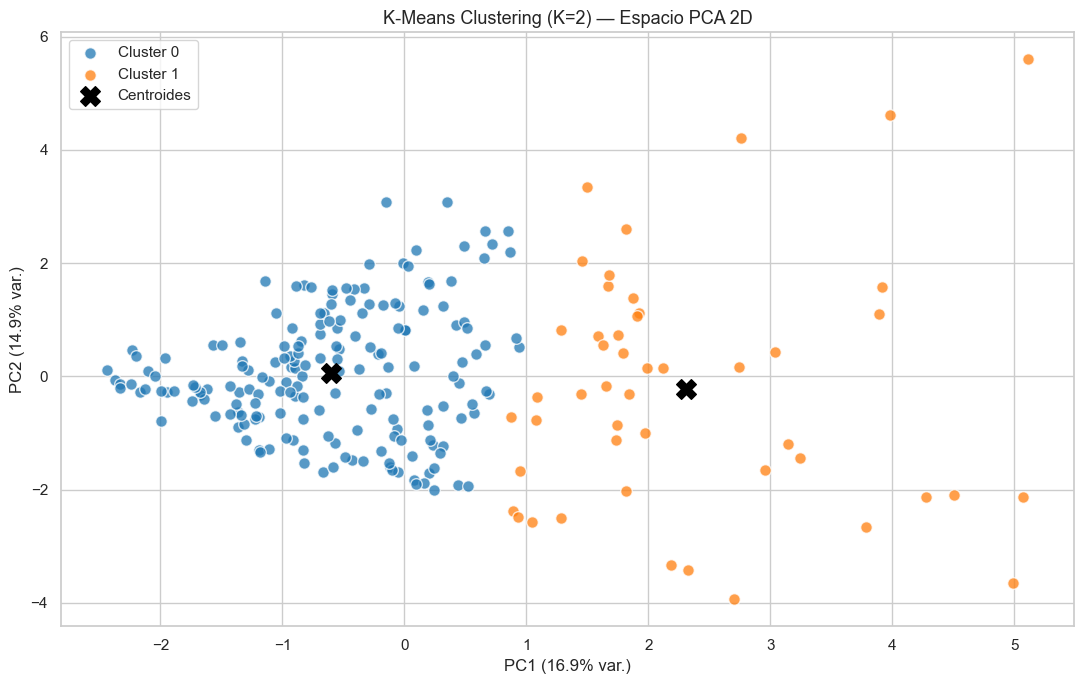

Cluster 0: 184 empleados
Cluster 1: 48 empleados


In [36]:
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

palette_c = sns.color_palette('tab10', n_colors=k_optimo)
plt.figure(figsize=(11, 7))
for k in range(k_optimo):
    mask = cluster_labels == k
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=[palette_c[k]], label=f'Cluster {k}', alpha=0.75, s=70, edgecolors='white')

centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroides')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)')
plt.title(f'K-Means Clustering (K={k_optimo}) — Espacio PCA 2D', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/01_kmeans_clusters.png', bbox_inches='tight', dpi=120)
plt.show()

for k in range(k_optimo):
    print(f'Cluster {k}: {(cluster_labels == k).sum()} empleados')

In [37]:
df_cluster = X_unsup.copy()
df_cluster['cluster'] = cluster_labels
df_cluster[target_clf] = df.loc[X_unsup.index, target_clf].values

profile_cols = [c for c in ['avg_desempeno', 'avg_competencias_tecnicas',
                             'avg_competencias_blandas', 'total_dias_ausencia',
                             'total_horas_capacitacion'] if c in df_cluster.columns]

print('=== PERFIL PROMEDIO POR CLUSTER ===')
print(df_cluster.groupby('cluster')[profile_cols].mean().round(3))

print('\n=== PROPORCIÓN ALTO DESEMPEÑO POR CLUSTER ===')
print(df_cluster.groupby('cluster')[target_clf].mean().round(3))

=== PERFIL PROMEDIO POR CLUSTER ===
         total_dias_ausencia  total_horas_capacitacion
cluster                                               
0                      9.880                    38.522
1                     42.708                    91.333

=== PROPORCIÓN ALTO DESEMPEÑO POR CLUSTER ===
cluster
0    0.538
1    0.375
Name: alto_desempeno, dtype: float64


---
## 9. Resumen

| Aspecto | Resultado |
|---------|-----------|
| Dataset | 255 filas, sin nulos (post-Kedro) |
| PCA | Componentes para 90% varianza: ver celda |
| K-Means | K óptimo según Silhouette Score |
| Plots guardados | `results/plots/01_*.png` |
